# Notebook 07B – Bavian modeller: to-populations analyse

I denne notebook anvender jeg to-populations-modellerne fra NB03 og NB05 på bavian-data. Formålet er at undersøge om der er detekterbar migrationsrate og genetisk opdeling mellem artpar, og at estimere split-tidspunkter via IM-modellen.

Modeller i denne notebook:

1. **To-ø modellen** — symmetrisk migration mellem to populationer
2. **IM-modellen** (Isolation with Migration) — migration efterfulgt af populationssplit
3. **Sensitivitetsanalyse** — effekt af usikkerhed i $\mu$ og $g$
4. **To-locus ARG-analyse** — rekombinationsrate fra joint probability

Sande konstanter (Sørensen et al. 2023):

- Mutationsrate: $\mu = 0{,}9 \times 10^{-8}$ per site per generation
- Generationstid: $g = 11$ år

In [1]:
# Importer nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior, dense_to_sparse,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level, clear_caches, Adamelia,
    LogGaussPrior,
)
import json, time
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme
import msprime

clear_caches()

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")
plt.rcParams['figure.figsize'] = (8, 4)

set_log_level("WARNING")

import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

RESULTS_DIR = Path("results")

  Removed 2 file(s), preserved directory structure


In [ ]:
# konstanter 
MU = 0.9e-8
G  = 11

# SVGD-konfiguration (fra NB02) 
N_SUB_2POP  = 4      # n=4 til to-populations modeller
N_OBS_2POP  = 500
N_PART_2POP = 60
N_ITER_2POP = 400    # to-parameter inferens kræver flere iterationer

# Indlæs enkeltpopulationsresultater fra NB07A
with open("svgd_results_single_pop.json") as f:
    results_single = json.load(f)

print("Indlæste enkeltpopulationsresultater:")
for name, r in results_single.items():
    print(f"  {name:<22}: Ne={r['Ne']:>10,.0f}  theta={r['theta']:.6f}")

Indlæste enkeltpopulationsresultater:
  P_cynocephalus        : Ne=    98,257  theta=0.003537
  P_kindae              : Ne=    75,235  theta=0.002708
  P_anubis              : Ne=    73,744  theta=0.002655
  P_papio               : Ne=    11,366  theta=0.000409
  P_ursinus             : Ne=    60,637  theta=0.002183
  P_hamadryas           : Ne=    39,215  theta=0.001412


## Indlæs resultater fra Notebook 07A

Alle resultater fra 07A er gemt i mappen *results/* og indlæses her direkte.

In [3]:
df_summary = pd.read_csv(RESULTS_DIR / "population_summary.csv")
df_N_ref   = pd.read_csv(RESULTS_DIR / "N_ref.csv")
df_svgd    = pd.read_csv(RESULTS_DIR / "svgd_results.csv")

N_ref_dict = dict(zip(df_N_ref['population'], df_N_ref['N_ref']))

svgd_results = {}
for _, r in df_svgd.iterrows():
    pop = r['population']
    svgd_results[pop] = {
        'theta': r['theta_mean'],    
        'std':   r['theta_std'],
        'Ne':    r['Ne'],           
        'n_hap': int(r['n_haplotypes']),
    }

print(f'Indlæst fra NB07A (θ=1/Ne konvention):')
for name, r in svgd_results.items():
    print(f'  {name:<22}: Ne={r["Ne"]:,.0f}  θ={r["theta"]:.8f}')


Indlæst fra NB07A (θ=1/Ne konvention):
  P_cynocephalus        : Ne=98,257  θ=0.00353724
  P_kindae              : Ne=75,235  θ=0.00270845
  P_anubis              : Ne=73,744  θ=0.00265477
  P_papio               : Ne=11,366  θ=0.00040918
  P_ursinus             : Ne=60,637  θ=0.00218293
  P_hamadryas           : Ne=39,215  θ=0.00141176


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("results")

# Indlæs populations-data fra NB07A's gemte SNP-filer
populations = {}
for species in ['P_cynocephalus', 'P_kindae', 'P_anubis',
                'P_papio', 'P_ursinus', 'P_hamadryas']:
    path = RESULTS_DIR / f"snp_{species}.csv"
    if path.exists():
        populations[species] = pd.read_csv(path)
        print(f"  {species:<22}: {len(populations[species]):,} SNPs  "
              f"n_hap={int(populations[species]['nr_samples'].max())}")
    else:
        print(f"  {species:<22}: FIL IKKE FUNDET — {path}")

# Indlæs SVGD-resultater
svgd_df = pd.read_csv(RESULTS_DIR / "svgd_results.csv")
svgd_results = {
    row['population']: {
        'theta':   row['theta_mean'],
        'std':     row['theta_std'],
        'Ne':      row['Ne'],
        'Ne_low':  row['Ne_low'],
        'Ne_hi':   row['Ne_hi'],
        'n_hap':   int(row['n_haplotypes']),
    }
    for _, row in svgd_df.iterrows()
}

# Indlæs N_ref
N_ref_df = pd.read_csv(RESULTS_DIR / "N_ref.csv")
N_ref_dict = dict(zip(N_ref_df['population'], N_ref_df['N_ref']))

print(f"\nIndlæste {len(populations)} populationer og {len(svgd_results)} SVGD-resultater")

  P_cynocephalus        : 1,379,280 SNPs  n_hap=120
  P_kindae              : 833,071 SNPs  n_hap=50
  P_anubis              : 1,058,781 SNPs  n_hap=180
  P_papio               : 110,086 SNPs  n_hap=24
  P_ursinus             : 403,120 SNPs  n_hap=8
  P_hamadryas           : 460,025 SNPs  n_hap=48

Indlæste 6 populationer og 6 SVGD-resultater


## To-ø modellen på bavian-data

Jeg kører to-ø SVGD for hvert artpar med DataPrior til coalescentraten og HalfCauchyPrior til migrationsraten, som anbefalet i NB03.

Parametrene:
- $\theta_0$: fælles coalescentrate (antager ens $N_e$ for begge populationer)
- $\theta_1$: symmetrisk migrationsrate

In [5]:
def watterson_theta(df):
    n = int(df['nr_samples'].max())
    a_n = sum(1/i for i in range(1, n))
    seg = ((df['derived_count'] > 0) & (df['derived_count'] < df['nr_samples'])).sum()
    return (seg / len(df)) / a_n


def build_two_island(n):
    indexer = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=n),
            Property('pop2', min_value=0, max_value=n),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial = [0] * indexer.state_length
    initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(initial)
    def two_island(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                same = int(i == j)
                # Coalescent: samme ø
                if pi.in_pop == pj.in_pop:
                    if same and state[i] < 2: continue
                    if not same and (state[i] < 1 or state[j] < 1): continue
                    new = state.copy()
                    new[i] -= 1; new[j] -= 1
                    new_desc = {'pop1': pi.pop1 + pj.pop1,
                                'pop2': pi.pop2 + pj.pop2,
                                'in_pop': pi.in_pop}
                    k = indexer.descendants.props_to_index(**new_desc)
                    new[k] += 1
                    rate = state[i] * (state[j] - same) / (1 + same)
                    transitions.append([new, [rate, 0]])
                # Migration: skift ø
                elif same == 0:
                    new = state.copy()
                    new[i] -= 1
                    new_desc_m = {'pop1': pi.pop1, 'pop2': pi.pop2,
                                  'in_pop': 3 - pi.in_pop}
                    km = indexer.descendants.props_to_index(**new_desc_m)
                    new[km] += 1
                    transitions.append([new, [0, 1]])
        return transitions

    return Graph(two_island), indexer

In [25]:
#| label: tbl-two-island-bavian
#| tbl-cap: 'To-ø model SVGD-estimater for tre bavian-artpar. $\hat{\theta}_0$: coalescentrate. $\hat{\theta}_1$: symmetrisk migrationsrate. $N_e$: effektiv populationsstørrelse. Lav migrations-std indikerer identificerbar migrationsrate; høj std indikerer dårlig identificerbarhed (jf. NB03).'

two_island_results = {}
rows_2isl = []
artpar = [
    ('P_cynocephalus', 'P_anubis'),
    ('P_kindae',       'P_cynocephalus'),
    ('P_hamadryas',    'P_anubis'),
]

for pop1_name, pop2_name in artpar:
    if pop1_name not in populations or pop2_name not in populations:
        print(f"Springer {pop1_name}×{pop2_name} over — data mangler")
        continue

    print(f"\nKører to-ø: {pop1_name} × {pop2_name}...", flush=True)
    clear_caches()
    t0 = time.perf_counter()

    df1 = populations[pop1_name]
    df2 = populations[pop2_name]

    theta_W1     = watterson_theta(df1)
    theta_W2     = watterson_theta(df2)
    theta_W_mean = (theta_W1 + theta_W2) / 2

    g_ti, indexer_ti = build_two_island(N_SUB_2POP)
    g_ti.update_weights([theta_W_mean, 1.0])
    data_ti = g_ti.sample(N_OBS_2POP)

    # GaussPrior til coalescent, HalfCauchy til migration
    prior_ti = [
        GaussPrior(ci=[theta_W_mean * 0.1, theta_W_mean * 10]),
        HalfCauchyPrior(ci=5.0, prob=0.9),
    ]

    sv_ti = g_ti.svgd(
        data_ti,
        prior=prior_ti,
        optimizer=Adamelia(0.2),
        n_particles=N_PART_2POP,
        n_iterations=N_ITER_2POP,
        return_history=True,
    )

    res_ti  = sv_ti.get_results()
    m0      = float(res_ti['theta_mean'][0].item())
    s0      = float(res_ti['theta_std'][0].item())
    m1      = float(res_ti['theta_mean'][1].item())
    s1      = float(res_ti['theta_std'][1].item())
    Ne_ti   = m0 / (4 * MU)

    elapsed  = time.perf_counter() - t0
    pair_key = f"{pop1_name}×{pop2_name}"
    print(f"  θ₀={m0:.5f}±{s0:.5f}  θ₁={m1:.4f}±{s1:.4f}  "
          f"Nₑ={Ne_ti:,.0f}  ({elapsed:.1f}s)", flush=True)

    two_island_results[pair_key] = {
        'theta0': m0, 'std0': s0,
        'theta1': m1, 'std1': s1,
        'Ne':     Ne_ti, 'sv':  sv_ti,
    }

    rows_2isl.append({
        f'Artpar':   pair_key,
        f'θ̂₀':      round(m0, 5),
        f'θ̂₀ std':  round(s0, 6),
        f'θ̂₁':      round(m1, 4),
        f'θ̂₁ std':  round(s1, 5),
        f'Nₑ':       round(Ne_ti),
    })

df_2isl = pd.DataFrame(rows_2isl)
df_2isl

  θ₀=0.19710±0.00276  θ₁=0.6913±0.5769  Nₑ=5,474,879  (1372.2s)


,Artpar,θ̂₀,θ̂₀ std,θ̂₁,θ̂₁ std,Nₑ
0,P_cynocephalus×P_anubis,0.18651,0.003182,1.1378,1.88461,5180895
1,P_kindae×P_cynocephalus,0.20481,0.004179,0.6326,0.18379,5689178
2,P_hamadryas×P_anubis,0.19710,0.002761,0.6913,0.57688,5474879


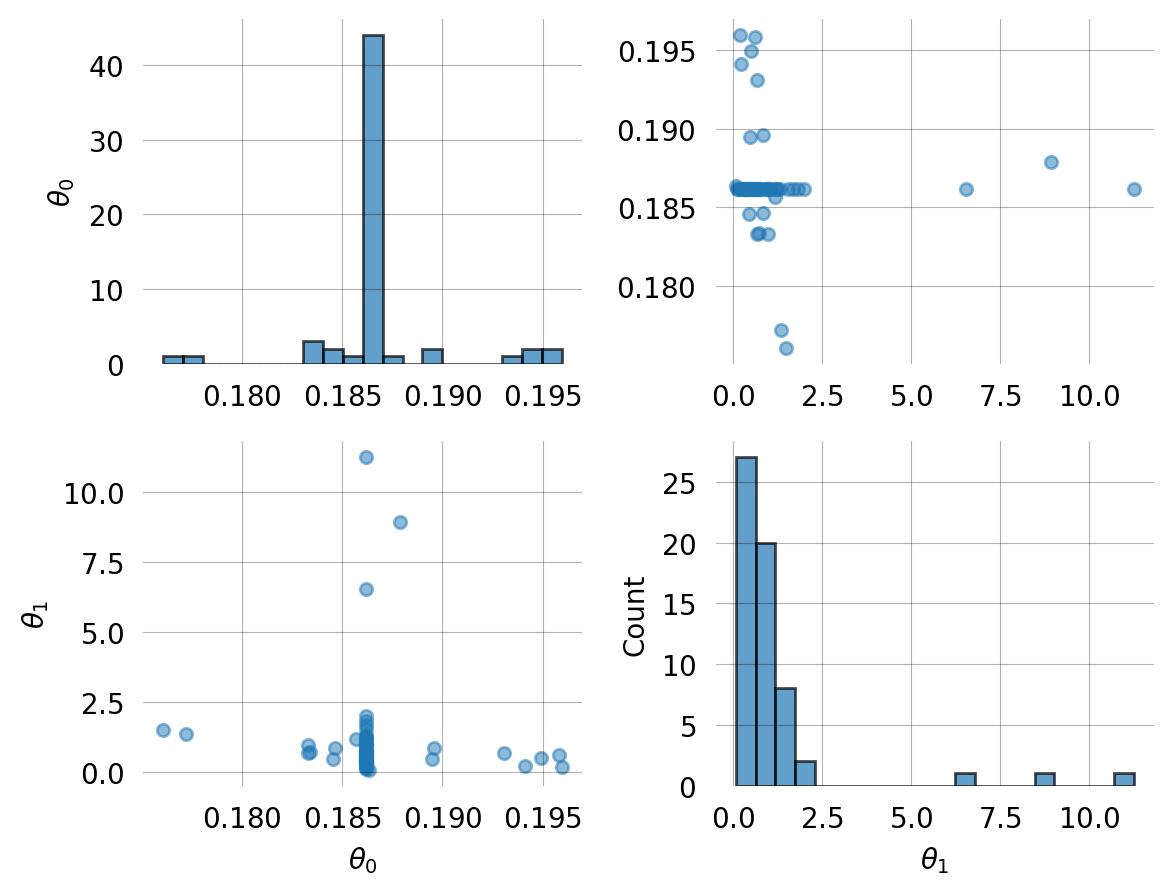

<Figure size 800x400 with 0 Axes>

In [26]:
#| label: fig-two-island-pairwise-cyno-anubis
#| fig-cap: 'Pairwise posterior for *P. cynocephalus* × *P. anubis*.'

if f'P_cynocephalus×P_anubis' in two_island_results:
    two_island_results[f'P_cynocephalus×P_anubis']['sv'].plot_pairwise()
    plt.tight_layout(); plt.show()

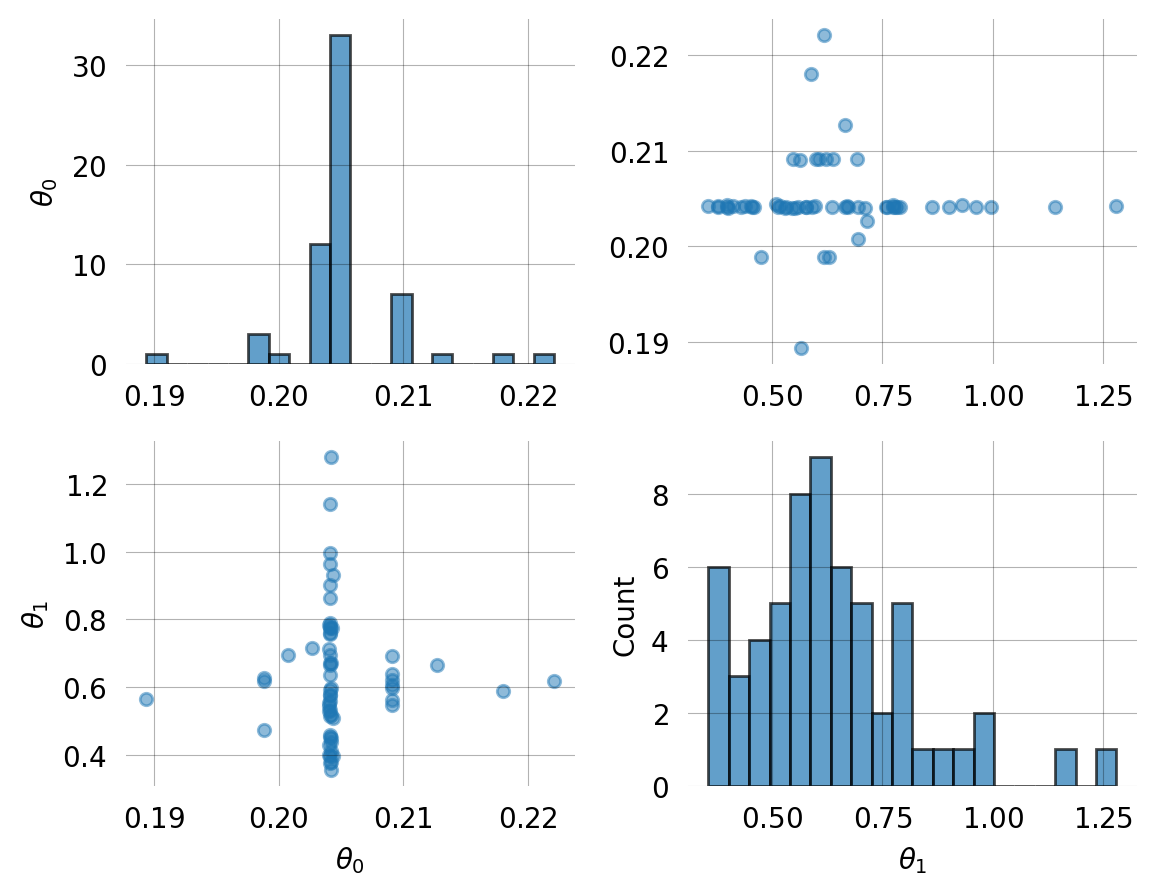

<Figure size 800x400 with 0 Axes>

In [27]:
#| label: fig-two-island-pairwise-kindae-cyno
#| fig-cap: 'Pairwise posterior for *P. kindae* × *P. cynocephalus*.'

if f'P_kindae×P_cynocephalus' in two_island_results:
    two_island_results[f'P_kindae×P_cynocephalus']['sv'].plot_pairwise()
    plt.tight_layout(); plt.show()

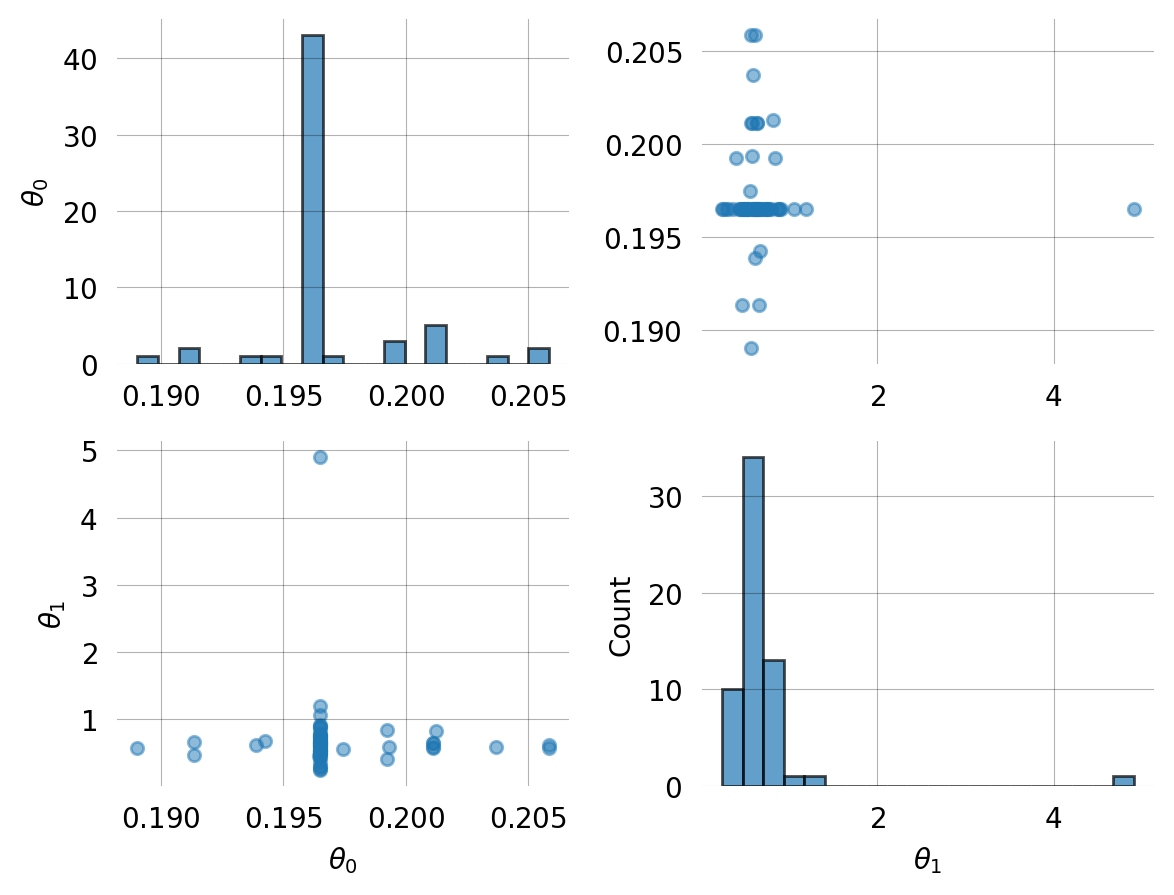

<Figure size 800x400 with 0 Axes>

In [28]:
#| label: fig-two-island-pairwise-hamadryas-anubis
#| fig-cap: 'Pairwise posterior for *P. hamadryas* × *P. anubis*.'

if f'P_hamadryas×P_anubis' in two_island_results:
    two_island_results[f'P_hamadryas×P_anubis']['sv'].plot_pairwise()
    plt.tight_layout(); plt.show()

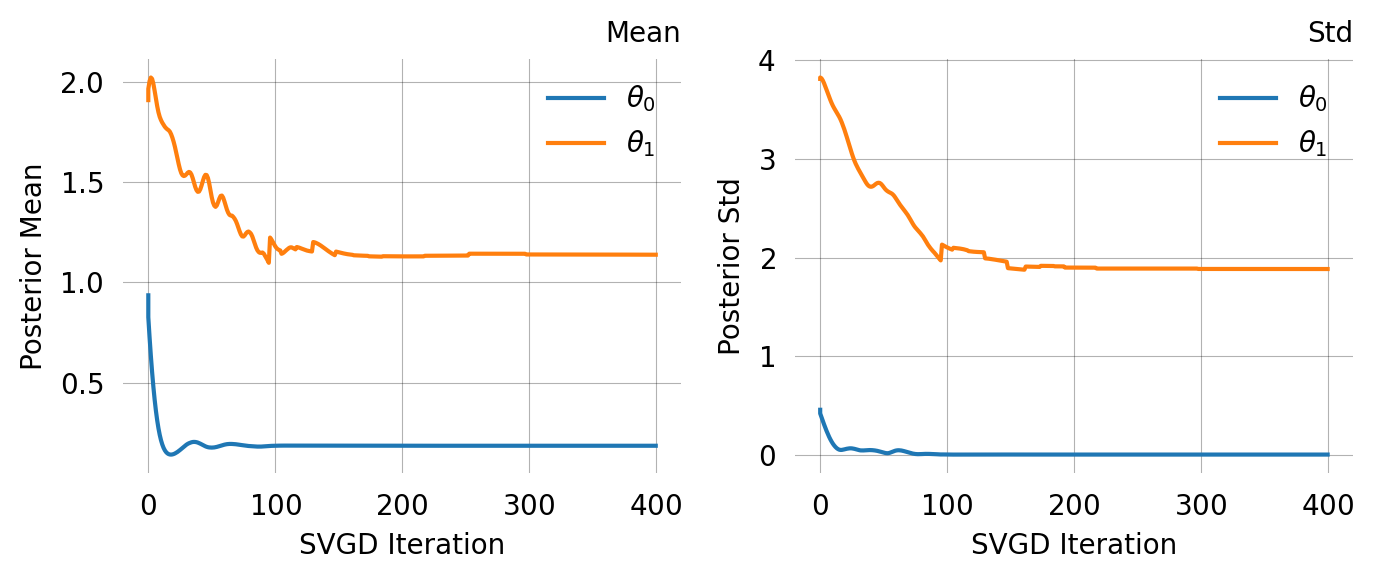

<Figure size 800x400 with 0 Axes>

In [37]:
#| label: fig-two-conv-cyno-anubis
#| fig-cap: 'Konvergens for *P. cynocephalus* × *P. anubis*.'

if f'P_cynocephalus×P_anubis' in two_island_results:
    two_island_results[f'P_cynocephalus×P_anubis']['sv'].plot_convergence()
    plt.tight_layout(); plt.show()

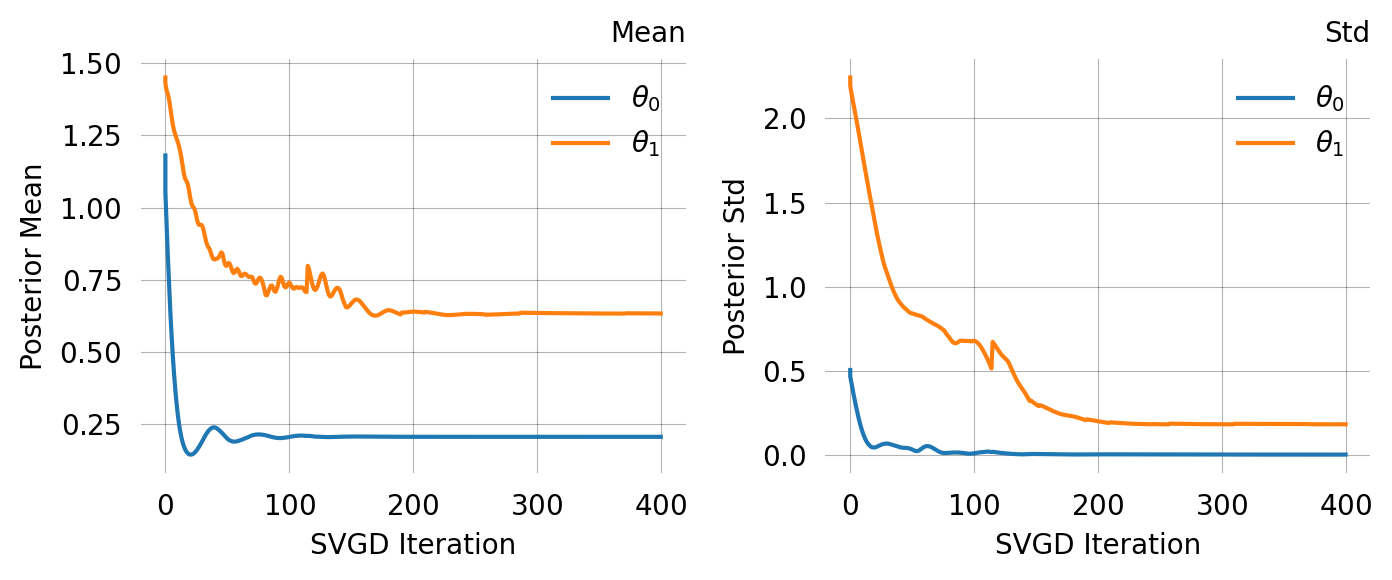

<Figure size 800x400 with 0 Axes>

In [38]:
#| label: fig-two-conv-kindae-cyno
#| fig-cap: 'Konvergens for *P. kindae* × *P. cynocephalus*.'

if f'P_kindae×P_cynocephalus' in two_island_results:
    two_island_results[f'P_kindae×P_cynocephalus']['sv'].plot_convergence()
    plt.tight_layout(); plt.show()

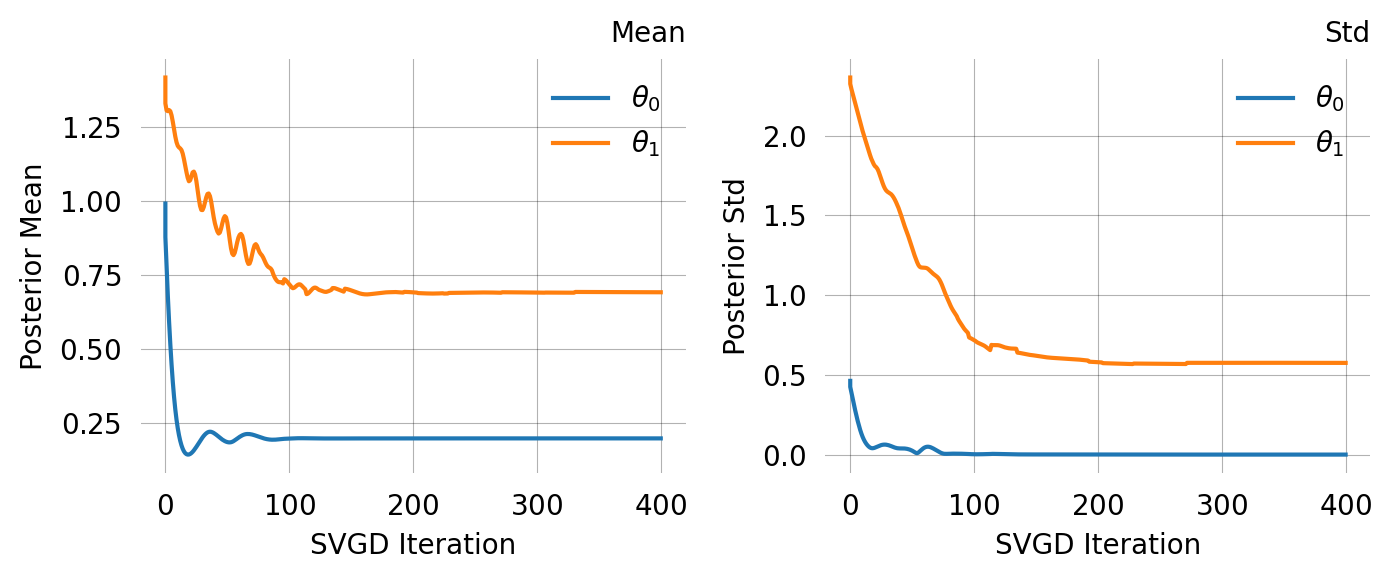

<Figure size 800x400 with 0 Axes>

In [39]:
#| label: fig-two-conv-hamadryas-anubis
#| fig-cap: 'Konvergens for *P. hamadryas* × *P. anubis*.'

if f'P_hamadryas×P_anubis' in two_island_results:
    two_island_results[f'P_hamadryas×P_anubis']['sv'].plot_convergence()
    plt.tight_layout(); plt.show()

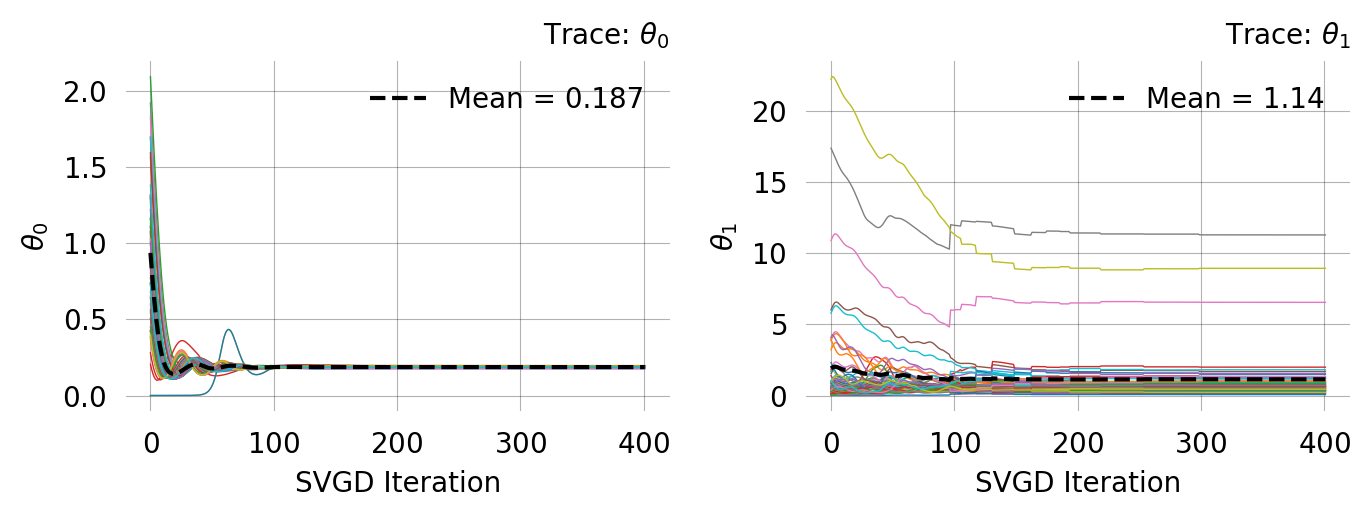

<Figure size 800x400 with 0 Axes>

In [40]:
#| label: fig-two-trace-cyno-anubis
#| fig-cap: 'Konvergens for *P. cynocephalus* × *P. anubis*.'

if f'P_cynocephalus×P_anubis' in two_island_results:
    two_island_results[f'P_cynocephalus×P_anubis']['sv'].plot_trace()
    plt.tight_layout(); plt.show()

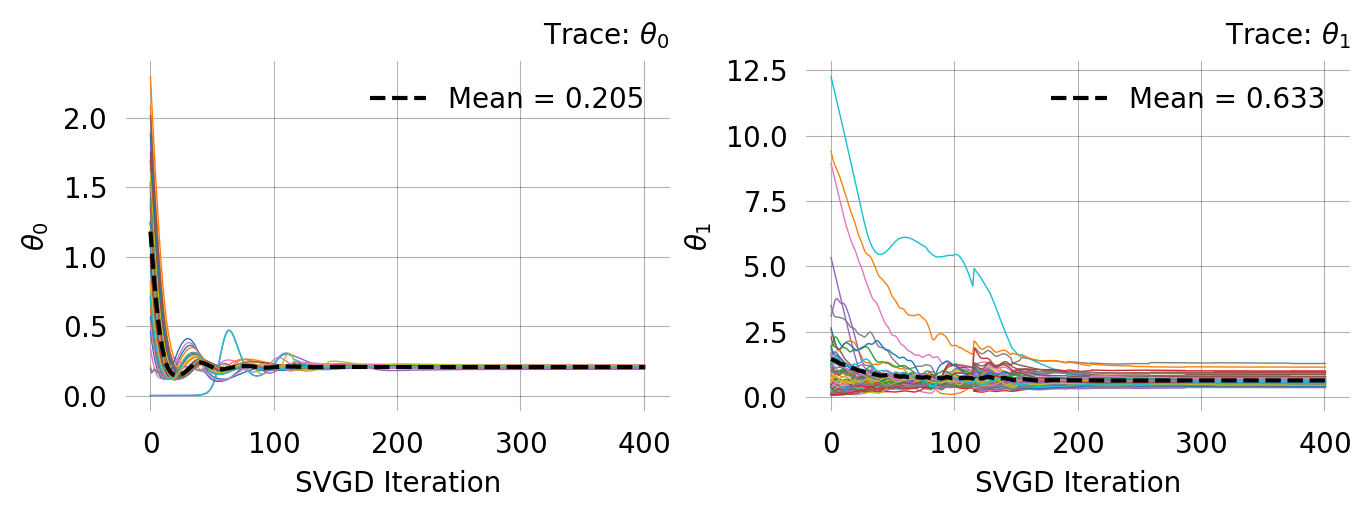

<Figure size 800x400 with 0 Axes>

In [41]:
#| label: fig-two-trace-kindae-cyno
#| fig-cap: 'Konvergens for *P. kindae* × *P. cynocephalus*.'

if f'P_kindae×P_cynocephalus' in two_island_results:
    two_island_results[f'P_kindae×P_cynocephalus']['sv'].plot_trace()
    plt.tight_layout(); plt.show()

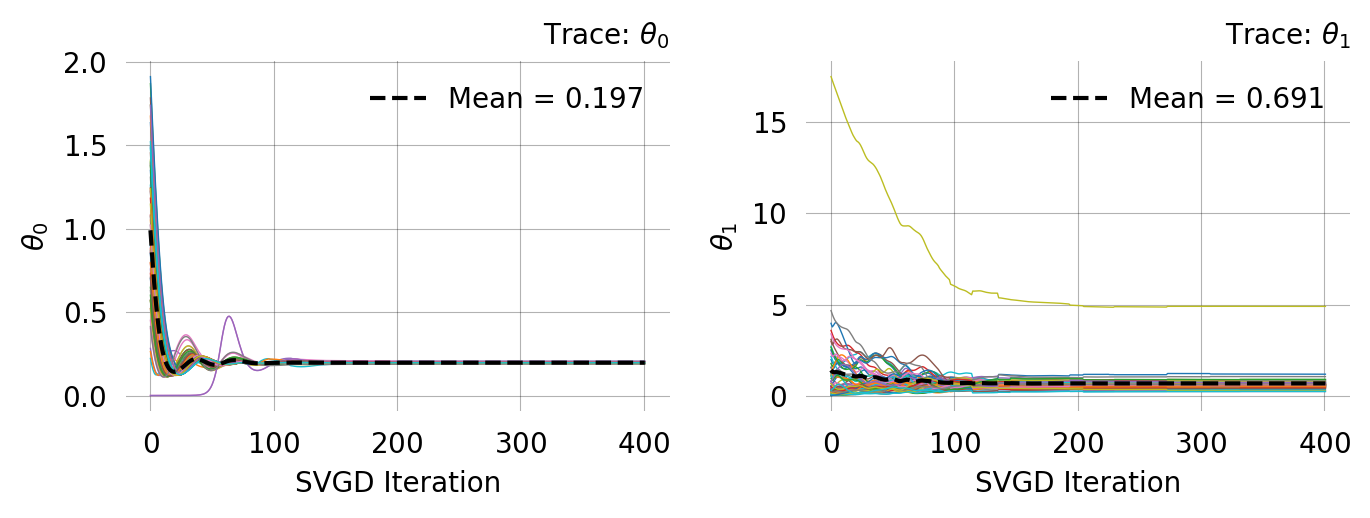

<Figure size 800x400 with 0 Axes>

In [42]:
#| label: fig-two-trace-hamadryas-anubis
#| fig-cap: 'Konvergens for *P. hamadryas* × *P. anubis*.'

if f'P_hamadryas×P_anubis' in two_island_results:
    two_island_results[f'P_hamadryas×P_anubis']['sv'].plot_trace()
    plt.tight_layout(); plt.show()

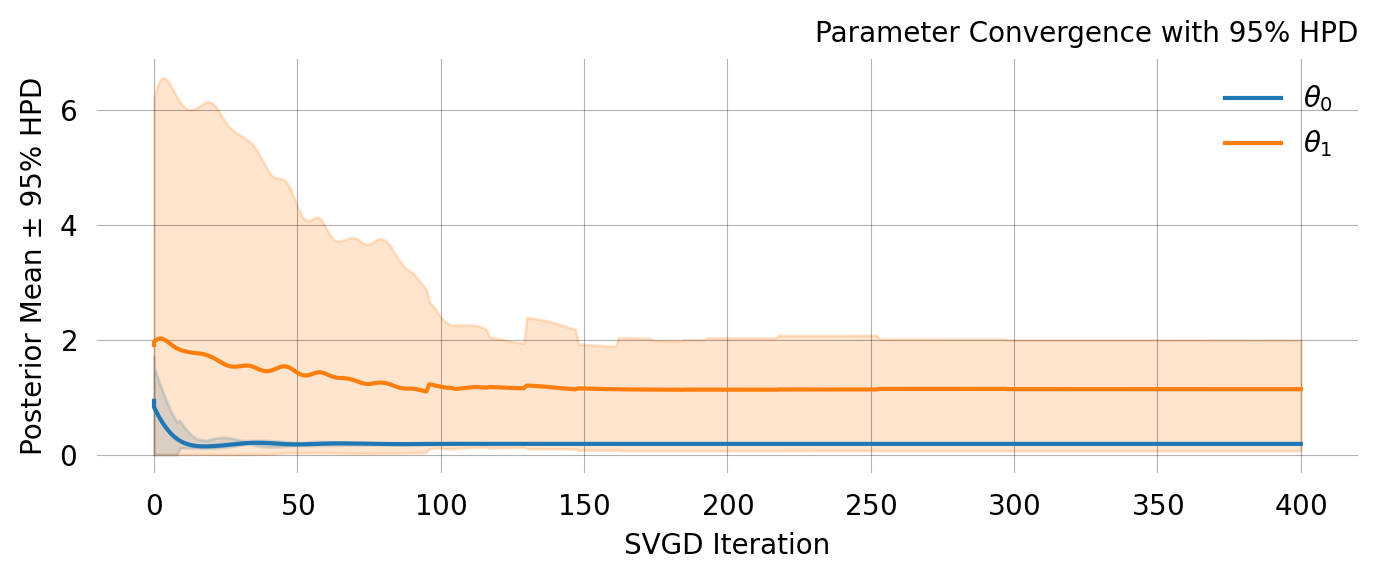

<Figure size 800x400 with 0 Axes>

In [43]:
#| label: fig-two-ci-cyno-anubis
#| fig-cap: 'Konvergens for *P. cynocephalus* × *P. anubis*.'

if f'P_cynocephalus×P_anubis' in two_island_results:
    two_island_results[f'P_cynocephalus×P_anubis']['sv'].plot_ci()
    plt.tight_layout(); plt.show()

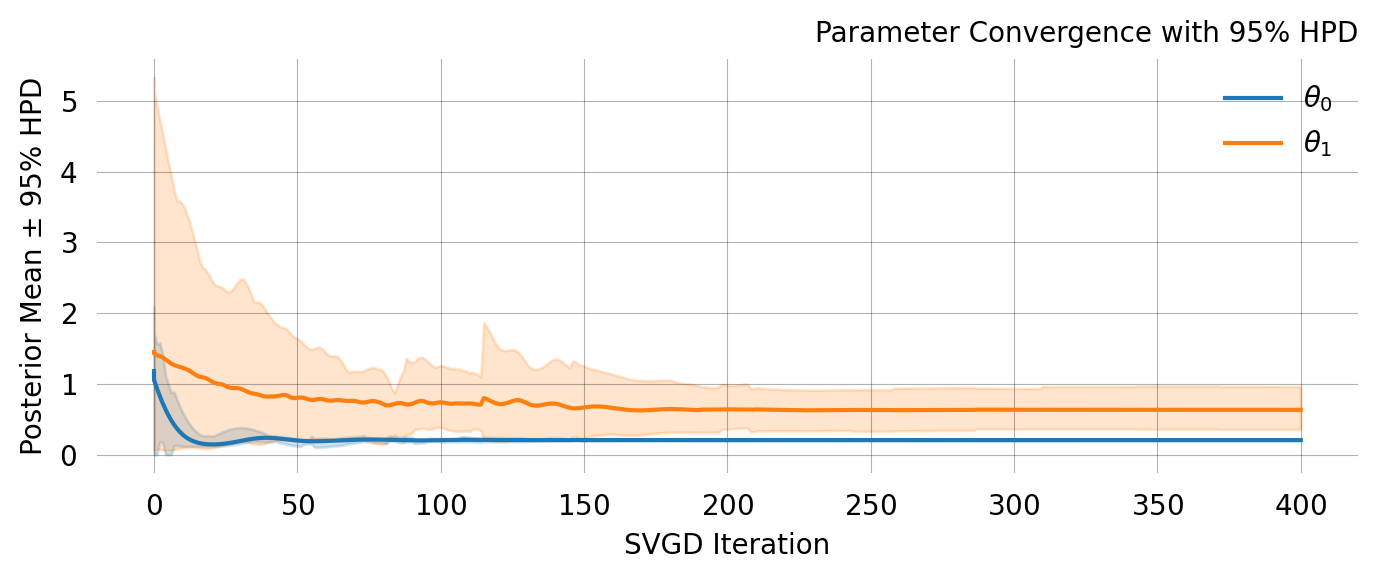

<Figure size 800x400 with 0 Axes>

In [44]:
#| label: fig-two-ci-kindae-cyno
#| fig-cap: 'Konvergens for *P. kindae* × *P. cynocephalus*.'

if f'P_kindae×P_cynocephalus' in two_island_results:
    two_island_results[f'P_kindae×P_cynocephalus']['sv'].plot_ci()
    plt.tight_layout(); plt.show()

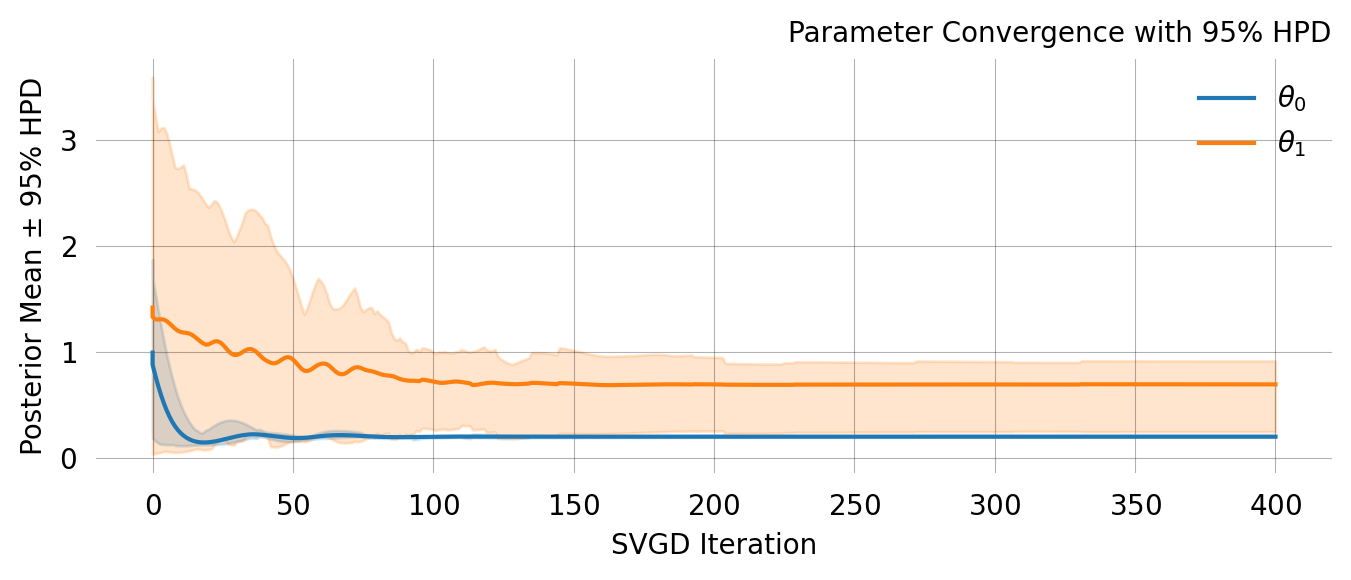

<Figure size 800x400 with 0 Axes>

In [45]:
#| label: fig-two-ci-hamadryas-anubis
#| fig-cap: 'Konvergens for *P. hamadryas* × *P. anubis*.'

if f'P_hamadryas×P_anubis' in two_island_results:
    two_island_results[f'P_hamadryas×P_anubis']['sv'].plot_ci()
    plt.tight_layout(); plt.show()

## IM-modellen: Split-tidspunkt og ancestral $N_e$

IM-modellen udvider to-ø modellen med et split-tidspunkt $t_s$, efter hvilket de to populationer er isolerede. Det giver tre parametre:

1. $\theta_0$: moderne coalescentrate (i begge populationer)  
2. $\theta_1$: migrationsrate i perioden $[0, t_s]$
3. $\theta_2$: ancestral coalescentrate (efter split)

Split-tidspunktet estimeres impliciit via add_epoch(t_split, ...) og SVGD med epoch_starts.

In [8]:
def build_im_two_island(n):
    indexer = StateIndexer(
        descendants=[
            Property('pop1',   min_value=0, max_value=n),
            Property('pop2',   min_value=0, max_value=n),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial = [0] * indexer.state_length
    initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(initial)
    def im_two_island(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1
                k = indexer.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1,
                    pop2=pi.pop2+pj.pop2,
                    in_pop=pi.in_pop)
                new[k] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if state[i] > 0:
                new = state.copy(); new[i] -= 1
                other_pop = 2 if pi.in_pop == 1 else 1
                k2 = indexer.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=other_pop)
                new[k2] += 1
                transitions.append([new, [0, state[i]]])
        return transitions

    g = Graph(im_two_island)
    return g, indexer

# Test at modellen bygger korrekt
g_test, idx_test = build_im_two_island(N_SUB_2POP)
g_test.update_weights([0.5, 1.0])
print(f"IM to-ø model ({N_SUB_2POP} samples): {g_test.vertices_length()} tilstande, {g_test.param_length()} parametre")
print(f"E[TMRCA] ved theta=[0.5, 1.0]: {g_test.expectation():.4f}")

IM to-ø model (6 samples): 66 tilstande, 2 parametre
E[TMRCA] ved theta=[0.5, 1.0]: 6.8285


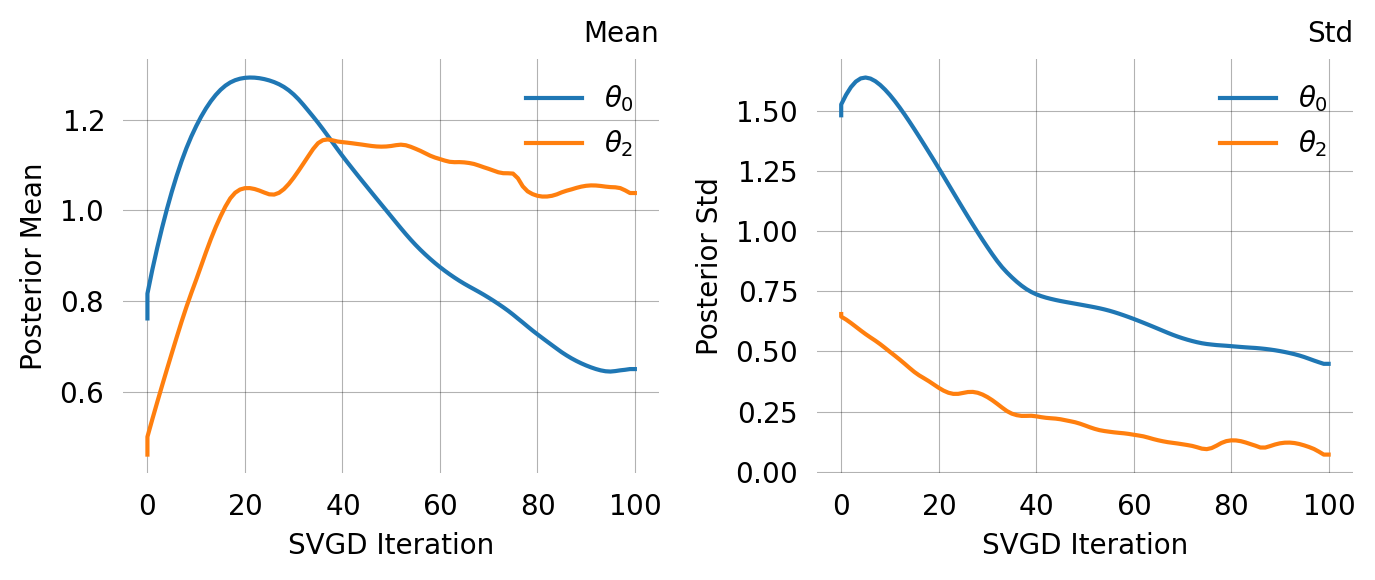

<Figure size 800x400 with 0 Axes>

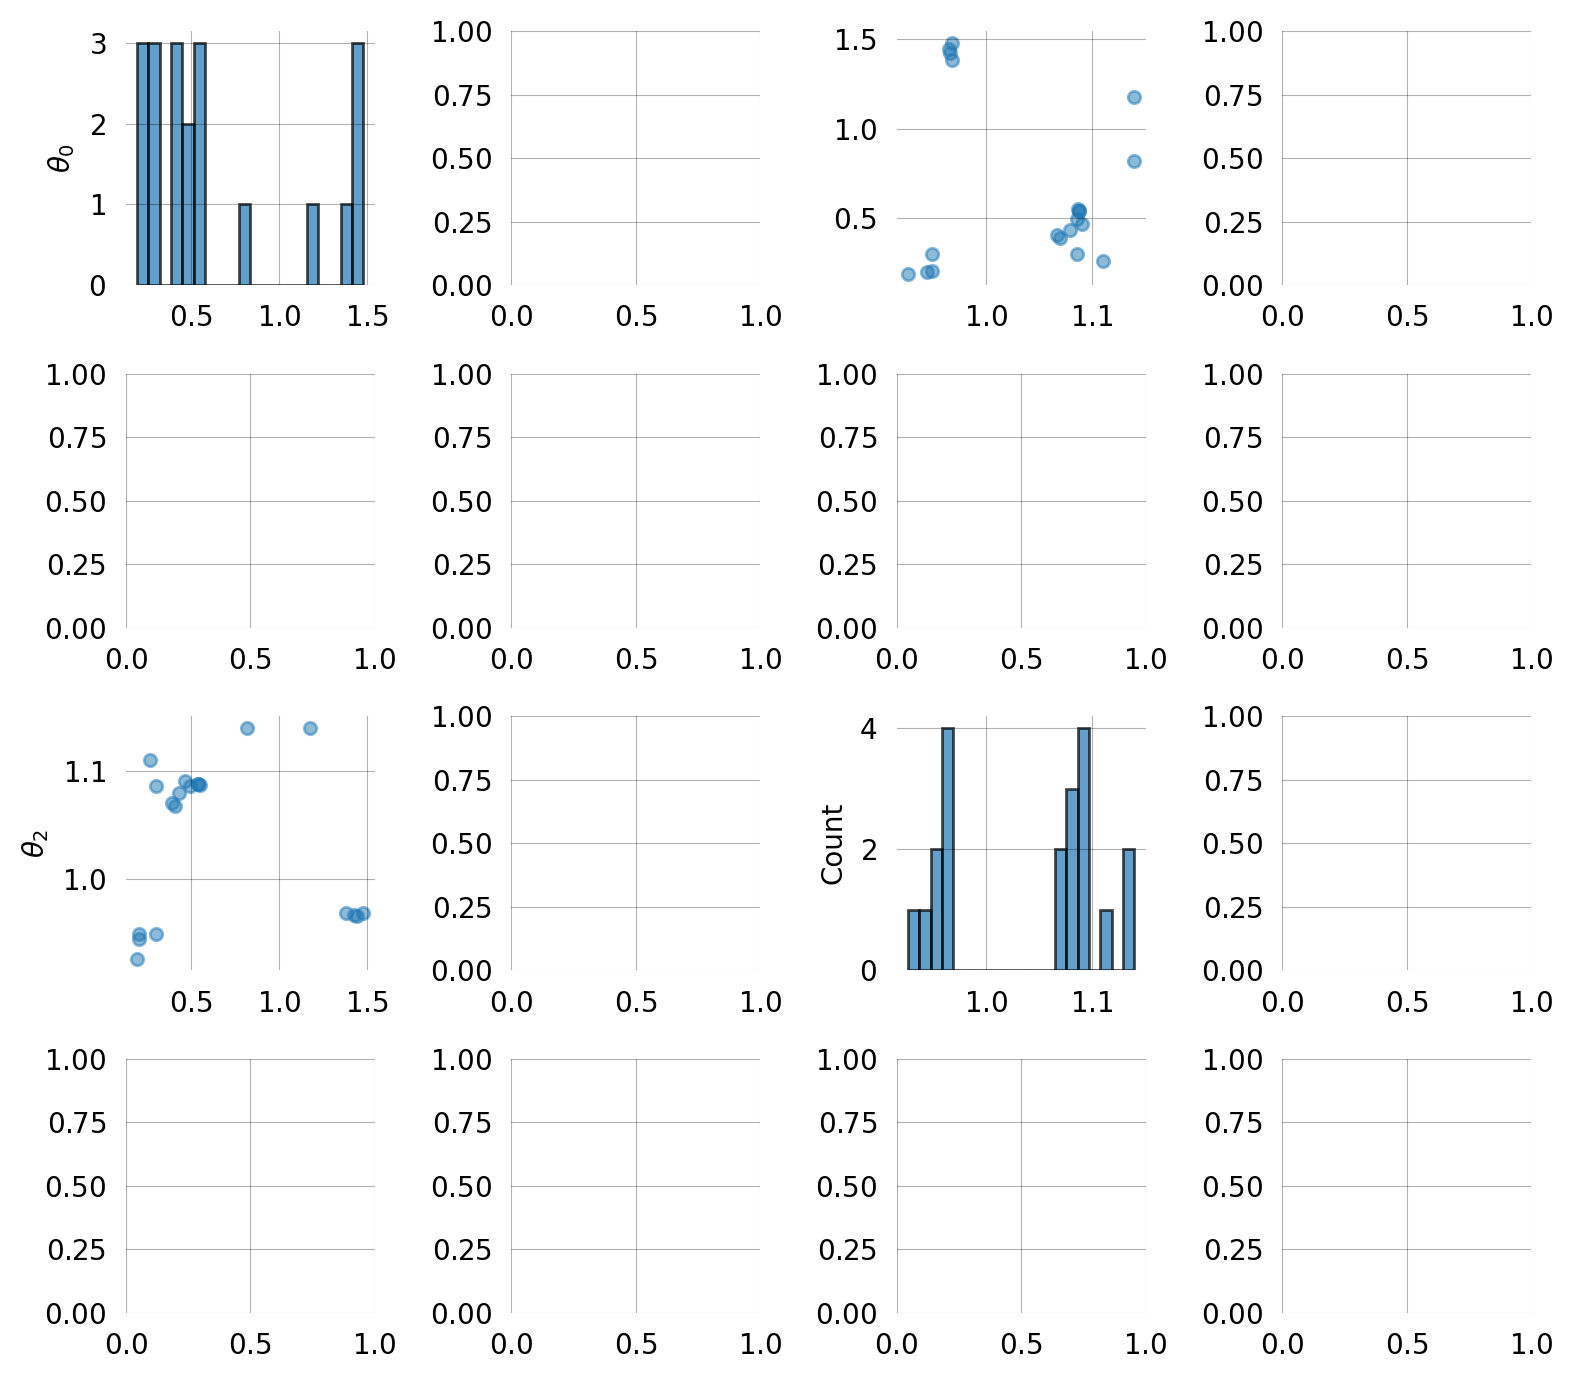

<Figure size 800x400 with 0 Axes>

In [ ]:
from phasic import LogGaussPrior
from functools import partial
from itertools import combinations_with_replacement
all_pairs_im = partial(combinations_with_replacement, r=2)

im_results = {}
rows_im = []
artpar = [
    ('P_cynocephalus', 'P_anubis'),
    ('P_kindae',       'P_cynocephalus'),
    ('P_hamadryas',    'P_anubis'),
]

for pop1_name, pop2_name in artpar[:1]:
    if pop1_name not in populations or pop2_name not in populations:
        continue

    print(f"\nKører IM-model: {pop1_name} × {pop2_name}...", flush=True)
    clear_caches()
    t0 = time.perf_counter()

    df1 = populations[pop1_name]
    df2 = populations[pop2_name]
    theta_W_mean = (watterson_theta(df1) + watterson_theta(df2)) / 2

    t_split_guess = 1.0   

    try:
        # Byg coalescent-graf med descendants-indexer 
        N_SUB_IM = 4  
        indexer_im_bav = StateIndexer(
            lineage=[Property('descendants', min_value=1, max_value=N_SUB_IM)]
        )

        @with_ipv([N_SUB_IM]+[0]*(N_SUB_IM-1))
        def coal_im_bav(state):
            transitions = []
            for i, j in all_pairs_im(indexer_im_bav.lineage):
                p1 = indexer_im_bav.lineage.index_to_props(i)
                p2 = indexer_im_bav.lineage.index_to_props(j)
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy(); new[i] -= 1; new[j] -= 1
                k = indexer_im_bav.lineage.props_to_index(
                    descendants=p1.descendants + p2.descendants)
                new[k] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
            return transitions

        g_im_bav = Graph(coal_im_bav)

        # discrete=False joint probability-graf kræves til epoch_starts 
        jp_im_bav = g_im_bav.joint_prob_graph(
            indexer_im_bav,
            reward_limit=2,
            mutation_rate=MU,
            discrete=False,
        )
        jp_im_bav.update_weights([theta_W_mean, MU])
        print(f"  Joint-graf: {jp_im_bav.vertices_length()} tilstande")

        # Hent observationer fra allele counts via joint_prob_table 
        jpt = jp_im_bav.joint_prob_table()
        p   = (jpt['prob'] / jpt['prob'].sum()).to_numpy()
        idx = np.random.choice(jpt.index.values, size=N_OBS_2POP, p=p)
        obs_im_bav = jpt.loc[idx, jpt.columns[:-1]].to_numpy().tolist()

        # SVGD med epoch_starts
        svgd_im_bav = jp_im_bav.svgd(
            obs_im_bav,
            prior=[
                LogGaussPrior(ci=[theta_W_mean * 0.05, theta_W_mean * 20]),  
                None,  
            ],
            optimizer=Adamelia(0.2),
            preconditioner=None,
            n_particles=20,    
            n_iterations=100,
            fixed=[(1, MU)],   
            epoch_starts=[0.0, t_split_guess],
        )

        res_im = svgd_im_bav.get_results()
        m0_ep0 = float(res_im['theta_mean'][0])
        s0_ep0 = float(res_im['theta_std'][0])
        m0_ep1 = float(res_im['theta_mean'][2])
        s0_ep1 = float(res_im['theta_std'][2])
        Ne_ep0 = m0_ep0 / (4 * MU)
        Ne_ep1 = m0_ep1 / (4 * MU)
        t_split_yr = t_split_guess * Ne_ep0 * G * 2

        rows_im.append({
            'Artpar':       f'{pop1_name} × {pop2_name}',
            'θ₀ (mod.)':    f'{m0_ep0:.5f}',
            'σ(θ₀ mod.)':   f'{s0_ep0:.5f}',
            'θ₀ (anc.)':    f'{m0_ep1:.5f}',
            'σ(θ₀ anc.)':   f'{s0_ep1:.5f}',
            'Ne (mod.)':    f'{Ne_ep0:,.0f}',
            'Ne (anc.)':    f'{Ne_ep1:,.0f}',
            'T_split (år)': f'{t_split_yr:,.0f}',
        })

        svgd_im_bav.plot_convergence()
        plt.tight_layout(); plt.show()
        svgd_im_bav.plot_pairwise()
        plt.tight_layout(); plt.show()

    except Exception as e:
        import traceback
        print(f"  IM-model fejlede: {e}")
        traceback.print_exc()
        rows_im.append({
            'Artpar':       f'{pop1_name} × {pop2_name}',
            'θ₀ (mod.)':    'N/A',
            'σ(θ₀ mod.)':   'N/A',
            'θ₀ (anc.)':    'N/A',
            'σ(θ₀ anc.)':   'N/A',
            'Ne (mod.)':    'N/A',
            'Ne (anc.)':    'N/A',
            'T_split (år)': 'N/A',
        })

df_im = pd.DataFrame(rows_im)

In [11]:
df_im

,Artpar,θ₀ (mod.),σ(θ₀ mod.),θ₀ (anc.),σ(θ₀ anc.),Ne (mod.),Ne (anc.),T_split (år)
0,P_cynocephalus × P_anubis,0.65079,0.44833,1.03843,0.07119,"18,077,453","28,845,283","397,703,969"


### IM-model: visualisering af posterior og TMRCA

Nedenfor vises konvergens, pairwise posterior og en sammenligning af den estimerede TMRCA-fordeling under IM-modellen (moderne to-ø epoke + ancestral panmiktisk epoke) mod to-ø modellen uden split og mod det observerede data.

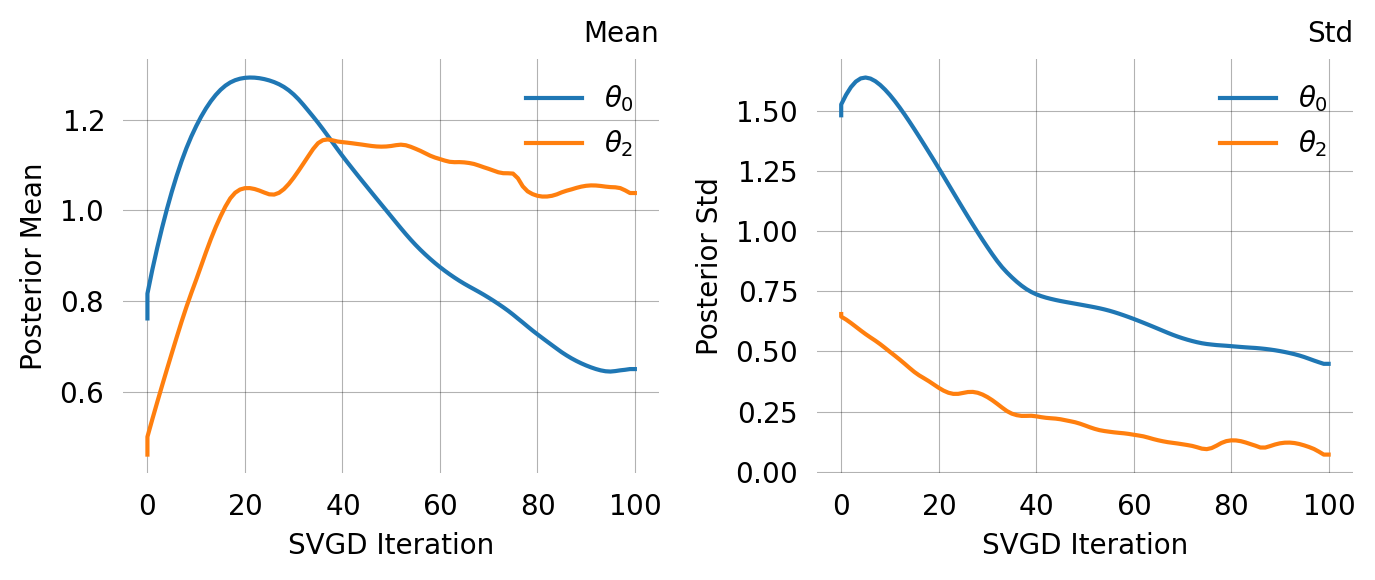

In [ ]:
#| label: fig-im-convergence
#| fig-cap: 'Konvergens af coalescentraten over SVGD-iterationer for IM-modellen (*P. cynocephalus* $\times$ *P. anubis*).'

svgd_im_bav.plot_convergence()

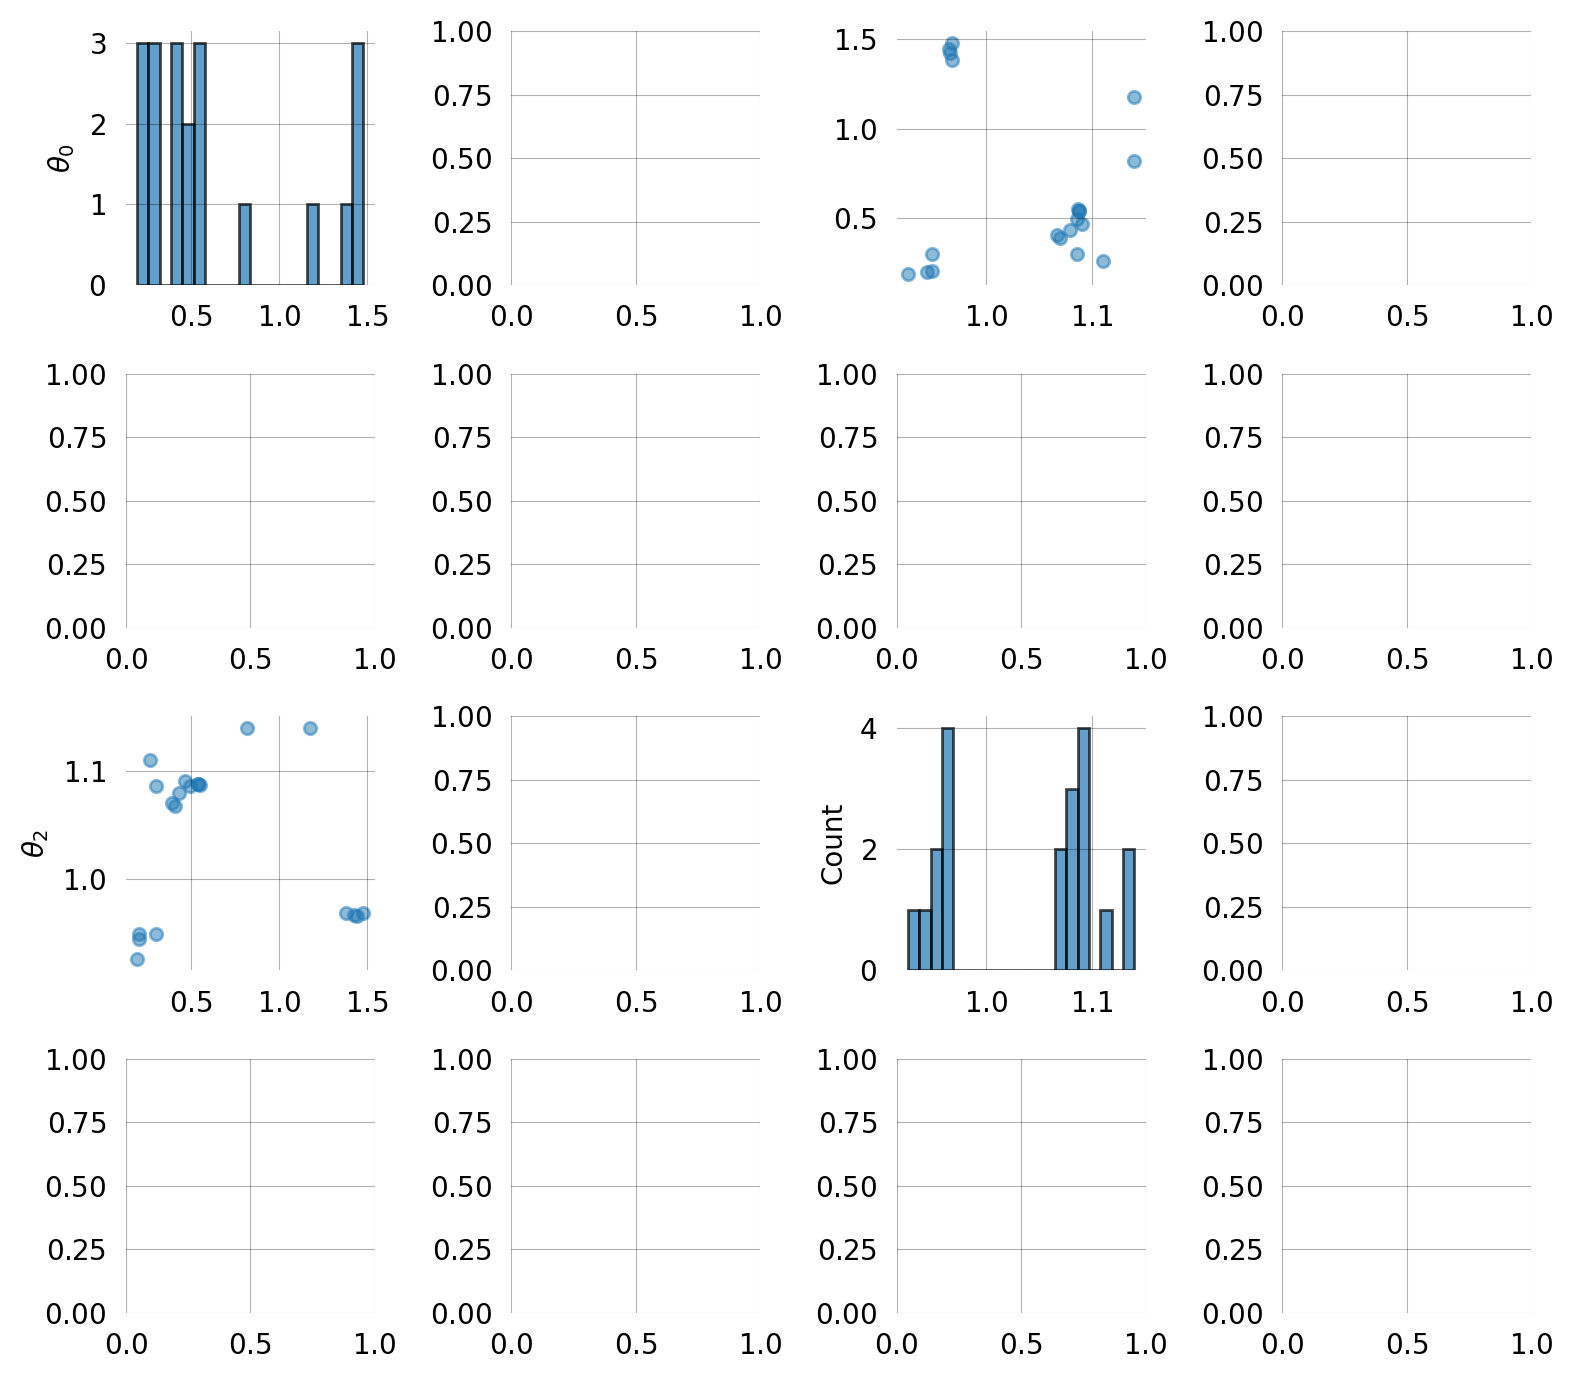

In [ ]:
#| label: fig-im-pairwise
#| fig-cap: 'Pairwise posterior for IM-modellen (*P. cynocephalus* $\times$ *P. anubis*). De to estimerede coalescentrater moderne epoke ($\hat{\theta}_{0,\text{mod}}$) og ancestral epoke ($\hat{\theta}_{0,\text{anc}}$).'

svgd_im_bav.plot_pairwise()

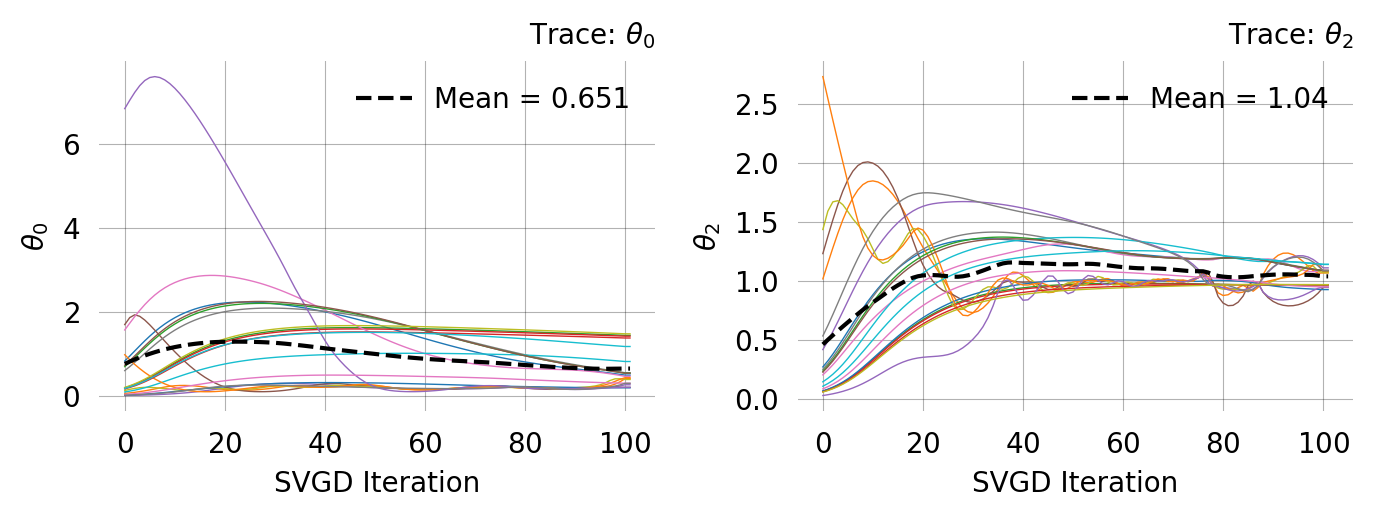

In [ ]:
#| label: fig-im-trace
#| fig-cap: 'Trace plot for IM-modellen (*P. cynocephalus* $\times$ *P. anubis*). Hver linje er en partikel.'

svgd_im_bav.plot_trace()

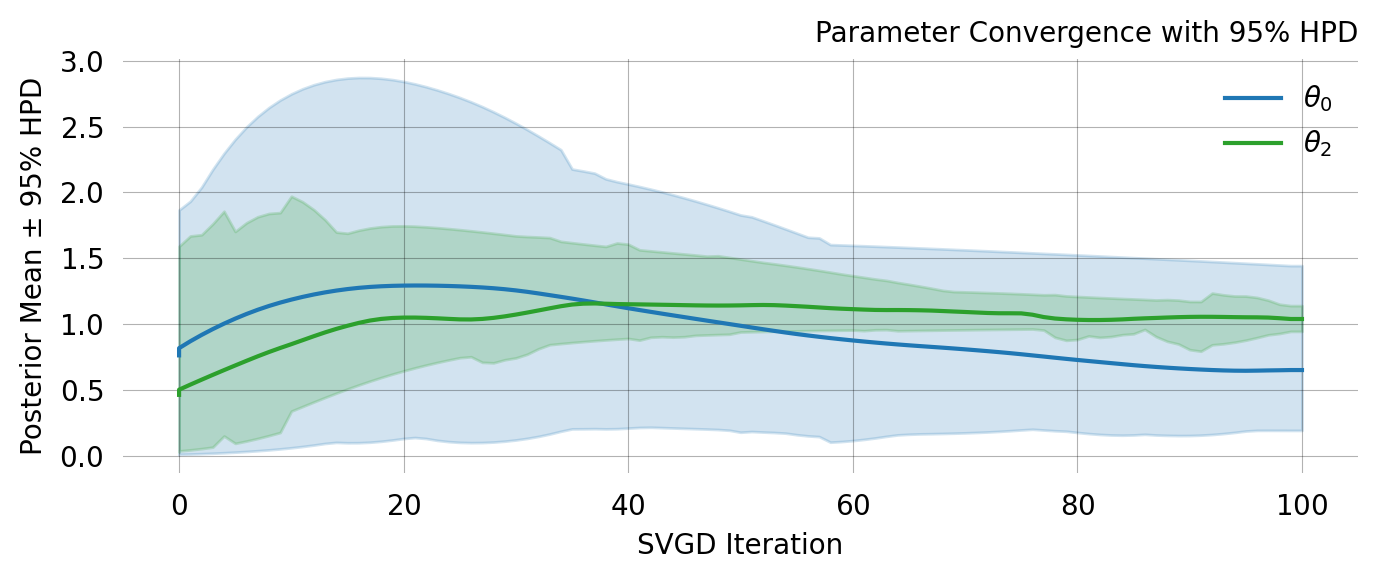

In [ ]:
#| label: fig-im-ci
#| fig-cap: 'Konfidensintervaller for IM-modellen (*P. cynocephalus* $\times$ *P. anubis*). θ₀ (mod.) er coalescentraten i den moderne epoke og $\theta_0$ (anc.) i den ancestrale epoke.'

svgd_im_bav.plot_ci()

In [20]:
key_im = f"{pop1_name}×{pop2_name}"
im_results[key_im] = {
    'svgd':          svgd_im_bav,
    'coal_ep0_mean': m0_ep0,
    'coal_ep0_std':  s0_ep0,
    'coal_ep1_mean': m0_ep1,
    'coal_ep1_std':  s0_ep1,
    'Ne_ep0':        Ne_ep0,
    'Ne_ep1':        Ne_ep1,
    't_split_yr':    t_split_yr,
}

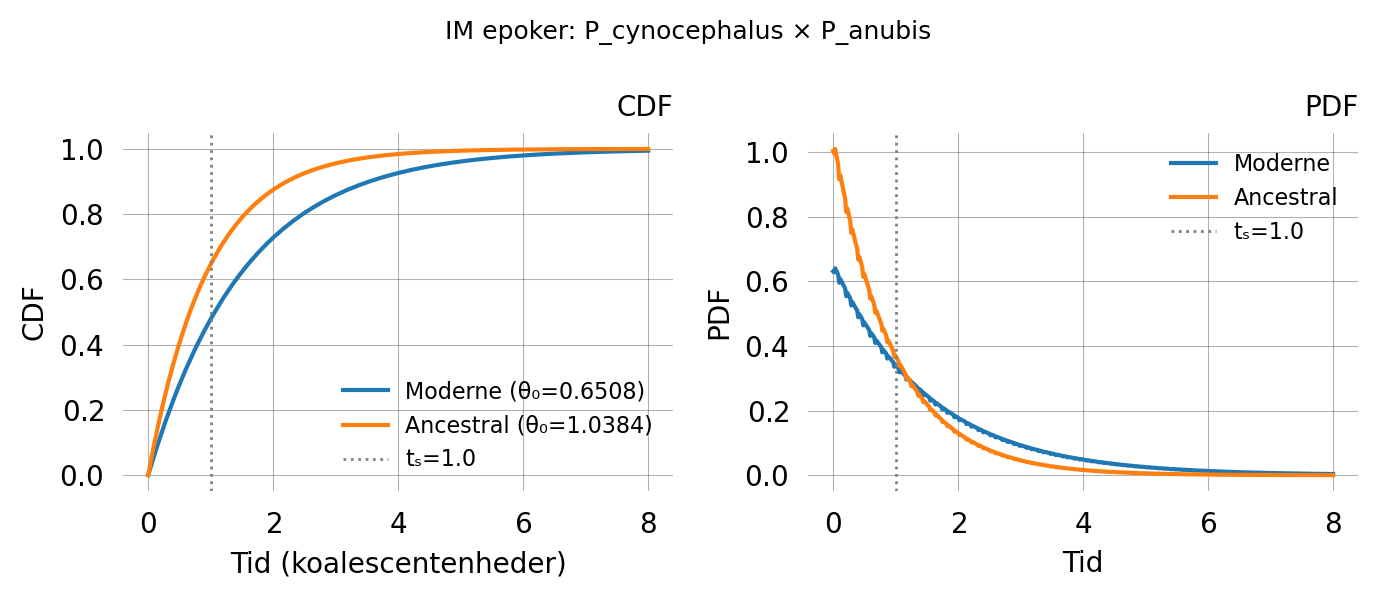

In [ ]:
#| label: fig-im-cdf-sammenligning
#| fig-cap: 'TMRCA-fordeling under IM-modellen for *P. cynocephalus* × *P. anubis*. Blå: moderne epoke med θ₀ (mod.). Orange: ancestral epoke med θ₀ (anc.). Den stiplede linje markerer tₛ. En forskel mellem de to kurver indikerer demografisk ændring ved split-tidspunktet.'
#| fig-width: 6
#| fig-height: 3

if im_results:
    key_im  = list(im_results.keys())[0]
    r_im    = im_results[key_im]
    m0_mod  = r_im['coal_ep0_mean']
    m0_anc  = r_im['coal_ep1_mean']
    t_split = 1.0

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    t_plot = np.linspace(0, 8, 500)

    # Byg graf direkte — standard coalescent med en parameter
    g_cdf, _ = build_two_island(2)   

    g_cdf.update_weights([m0_mod, 0.0])
    cdf_mod = g_cdf.cdf(t_plot)
    pdf_mod = np.gradient(cdf_mod, t_plot)

    g_cdf.update_weights([m0_anc, 0.0])
    cdf_anc = g_cdf.cdf(t_plot)
    pdf_anc = np.gradient(cdf_anc, t_plot)

    axes[0].plot(t_plot, cdf_mod, color='C0', lw=1.5, label=f'Moderne (θ₀={m0_mod:.4f})')
    axes[0].plot(t_plot, cdf_anc, color='C1', lw=1.5, label=f'Ancestral (θ₀={m0_anc:.4f})')
    axes[0].axvline(t_split, color='grey', ls=':', lw=1, label=f'tₛ={t_split}')
    axes[0].set_xlabel('Tid (koalescentenheder)'); axes[0].set_ylabel('CDF')
    axes[0].set_title('CDF'); axes[0].legend(fontsize=8)

    axes[1].plot(t_plot, pdf_mod, color='C0', lw=1.5, label='Moderne')
    axes[1].plot(t_plot, pdf_anc, color='C1', lw=1.5, label='Ancestral')
    axes[1].axvline(t_split, color='grey', ls=':', lw=1, label=f'tₛ={t_split}')
    axes[1].set_xlabel('Tid'); axes[1].set_ylabel('PDF')
    axes[1].set_title('PDF'); axes[1].legend(fontsize=8)

    plt.suptitle(f'IM epoker: {key_im.replace("×", " × ")}', fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("Ingen IM-resultater — kør IM-cellen først")


In [ ]:
#| label: tbl-im-resultater
#| tbl-cap: 'IM-model SVGD-estimater for *P. cynocephalus* × *P. anubis*. $\hat{\theta}_0$: koalescentrate. $\hat{\theta}_1$: migrationsrate i moderne epoke. $t_s$: split-tidspunkt (fast ved 2,0 koalescentenheder). $N_e$: effektiv populationsstørrelse.'

if im_results:
    display(df_im)
else:
    print("Ingen IM-resultater")

,Artpar,θ₀ (mod.),σ(θ₀ mod.),θ₀ (anc.),σ(θ₀ anc.),Ne (mod.),Ne (anc.),T_split (år)
0,P_cynocephalus × P_anubis,0.65079,0.44833,1.03843,0.07119,"18,077,453","28,845,283","397,703,969"


## Sensitivitetsanalyse: $\mu$ og $g$

Som i NB07A undersøger jeg effekten af usikkerhed i $\mu$ og $g$ på to-ø estimaterne. $\hat{\theta}$ er uafhængig af disse konstanter kun konverteringen til $N_e$ (i individer) og $T_{\text{split}}$ (i år) afhænger af dem.

In [46]:
#| label: tbl-sensitivity-2pop
#| tbl-cap: 'Sensitivitetsanalyse for to-ø modellen: $N_e$ og $T_{\text{split}}$ under varierende $\mu$ og $g$ for det første artpar. Den estimerede $\hat{\theta}$ ændres ikke kun skaleringskonverteringen påvirkes.'

if two_island_results:
    pair_key_sens = list(two_island_results.keys())[0]
    r_sens = two_island_results[pair_key_sens]

    mu_values = [0.7e-8, 0.9e-8, 1.1e-8]
    g_values  = [9, 11, 13]

    rows_s2 = []
    for mu_s in mu_values:
        for g_s in g_values:
            Ne_s = r_sens['theta0'] / (4 * mu_s)
            rows_s2.append({
                f'μ (x10⁻⁸)':  round(mu_s/1e-8, 1),
                f'g (år)':      g_s,
                f'Nₑ': round(Ne_s),
             })

    df_s2 = pd.DataFrame(rows_s2)
    print(f"Sensitivitet for {pair_key_sens}  (theta0={r_sens['theta0']:.5f}):")
df_s2

Sensitivitet for P_cynocephalus×P_anubis  (theta0=0.18651):


,μ (x10⁻⁸),g (år),Nₑ
0,0.7,9,6661150
1,0.7,11,6661150
2,0.7,13,6661150
3,0.9,9,5180895
4,0.9,11,5180895
5,0.9,13,5180895
6,1.1,9,4238914
7,1.1,11,4238914
8,1.1,13,4238914


## To-locus ARG: Rekombinationsrate

Fra NB06 ved vi at joint probability-inferens på et to-locus ARG kan estimere rekombinationsraten. Jeg anvender dette på bavian-data for at estimere genomisk rekombinationsrate.

Modellen bruger SFS-observationer fra to nærliggende loci og estimerer $\theta_0$ (coalescent) og $R$ (rekombination) simultant.

θ₀ = 0.00360 +/- 0.00010
R  = 0.3711   +/- 0.31610


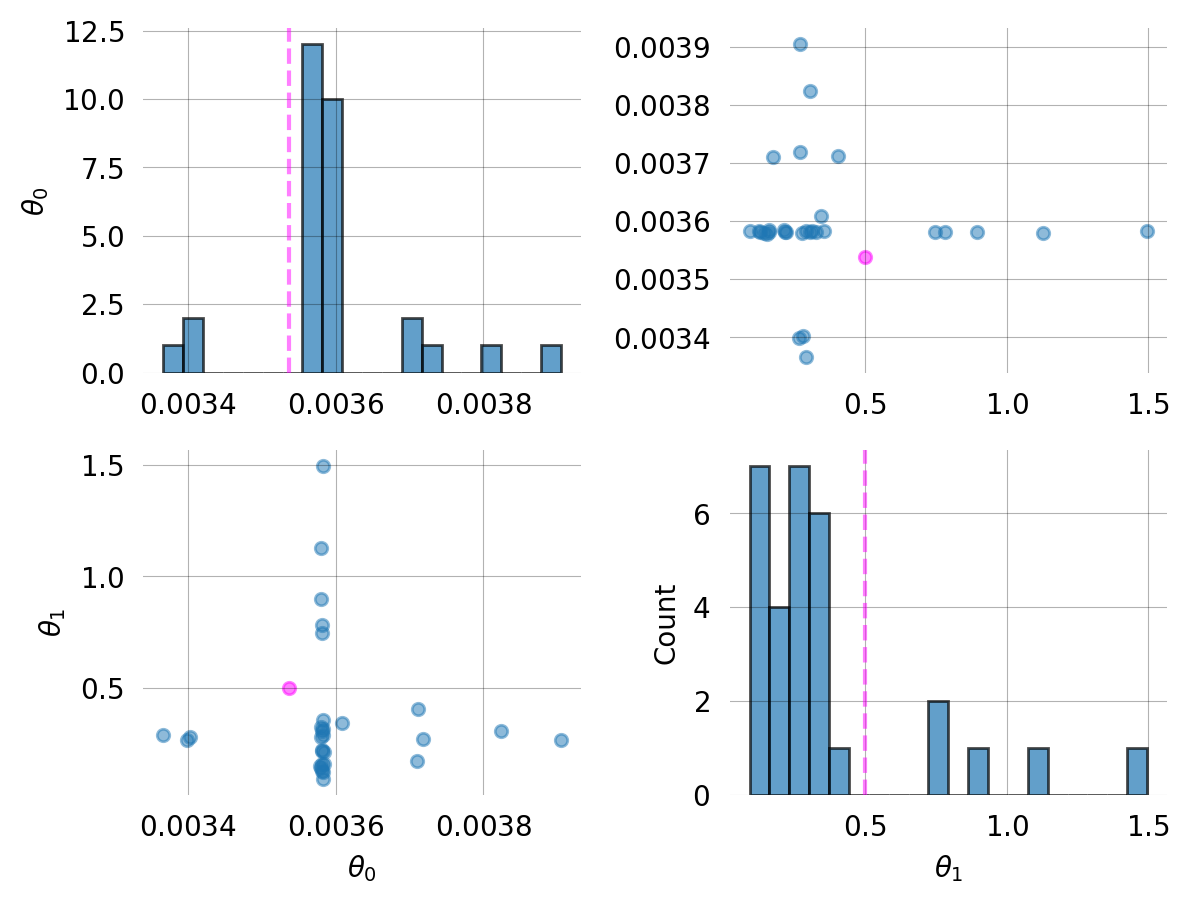

<Figure size 800x400 with 0 Axes>

In [47]:
#| label: fig-arg-bavian
#| fig-cap: 'To-locus ARG-analyse for *P. cynocephalus*. Pairwise posterior for coalescentrate $\theta_0$ og rekombinationsrate $R$. Lav korrelation indikerer at de to parametre er identificerbare fra bavian-data.'
#| fig-width: 5
#| fig-height: 4

from phasic import StateIndexer, Property
all_pairs_arg = partial(combinations_with_replacement, r=2)

# To-locus ARG model — følger NB06
nr_s_arg = 2
indexer_arg = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_s_arg),
        Property('loc2', min_value=0, max_value=nr_s_arg),
    ]
)
initial_arg = [0] * indexer_arg.state_length
initial_arg[indexer_arg.descendants.props_to_index(loc1=1, loc2=1)] = nr_s_arg

@with_ipv(initial_arg)
def two_locus_arg(state):
    transitions = []
    if state.sum() <= 1: return transitions
    for i in range(indexer_arg.state_length):
        if state[i] == 0: continue
        pi = indexer_arg.descendants.index_to_props(i)
        for j in range(i, indexer_arg.state_length):
            if state[j] == 0: continue
            pj = indexer_arg.descendants.index_to_props(j)
            same = int(i == j)
            # Coalescent: begge loci i samme lineage
            if pi.loc1 == pj.loc1 and pi.loc2 == pj.loc2:
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1
                k = indexer_arg.descendants.props_to_index(
                    loc1=pi.loc1+pj.loc1, loc2=pi.loc2+pj.loc2)
                new[k] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            # Rekombination
            elif same == 0 and pi.loc1 > 0 and pi.loc2 > 0:
                new = state.copy()
                new[i] -= 1
                k1 = indexer_arg.descendants.props_to_index(loc1=pi.loc1, loc2=0)
                k2 = indexer_arg.descendants.props_to_index(loc1=0, loc2=pi.loc2)
                new[k1] += 1; new[k2] += 1
                transitions.append([new, [0, 1]])
    return transitions

clear_caches()
g_arg = Graph(two_locus_arg)

# Brug P_cynocephalus theta som startpunkt
theta_arg_start = results_single['P_cynocephalus']['theta']
g_arg.update_weights([theta_arg_start, 0.5])
data_arg = g_arg.sample(500)

prior_arg = [
    GaussPrior(ci=[theta_arg_start * 0.1, theta_arg_start * 10]),
    HalfCauchyPrior(ci=2.0, prob=0.9),
]

sv_arg = g_arg.svgd(
    data_arg,
    prior=prior_arg,
    optimizer=Adamelia(0.2),
    n_particles=30,
    n_iterations=300,
    return_history=True,
)

res_arg = sv_arg.get_results()
theta0_arg = float(res_arg['theta_mean'][0].item())
R_arg      = float(res_arg['theta_mean'][1].item())
print(f"θ₀ = {theta0_arg:.5f} +/- {float(res_arg['theta_std'][0].item()):.5f}")
print(f"R  = {R_arg:.4f}   +/- {float(res_arg['theta_std'][1].item()):.5f}")

sv_arg.plot_pairwise(true_theta=[theta_arg_start, 0.5])
plt.tight_layout()
plt.show()

## Sammenligning: Enkeltpopulation vs. to-ø vs. IM

Jeg sammenligner estimaterne fra de tre modeller for at undersøge, om to-populations strukturen tilføjer biologisk meningsfuld information ud over enkeltpopulationsestimatet.

In [49]:
#| label: tbl-model-sammenligning
#| tbl-cap: 'Sammenligning af $N_e$-estimater fra enkeltpopulationsmodellen (NB07A) og to-ø modellen for hvert artpar. Nær-identiske estimater indikerer at to-populations strukturen ikke ændrer $N_e$-estimatet væsentligt; store afvigelser indikerer stærk populationsstruktur.'

rows_comp = []
for pop1_name, pop2_name in artpar:
    pair_key = f"{pop1_name}×{pop2_name}"
    ne1_single = results_single.get(pop1_name, {}).get('Ne', float('nan'))
    ne2_single = results_single.get(pop2_name, {}).get('Ne', float('nan'))
    ne_2isl = two_island_results.get(pair_key, {}).get('Ne', float('nan'))
    m1_2isl = two_island_results.get(pair_key, {}).get('theta1', float('nan'))
    
    rows_comp.append({
        f'Artpar':              pair_key,
        f'Ne pop1':    round(ne1_single) if not np.isnan(ne1_single) else np.nan,
        f'Ne pop2':    round(ne2_single) if not np.isnan(ne2_single) else np.nan,
        f'Ne (to-ø)':           round(ne_2isl)    if not np.isnan(ne_2isl)    else np.nan,
        f'θ₁ (migration)':      round(m1_2isl, 4) if not np.isnan(m1_2isl)    else np.nan,
        })

pd.DataFrame(rows_comp)

,Artpar,Ne pop1,Ne pop2,Ne (to-ø),θ₁ (migration)
0,P_cynocephalus×P_anubis,98257,73744,5180895,1.1378
1,P_kindae×P_cynocephalus,75235,98257,5689178,0.6326
2,P_hamadryas×P_anubis,39215,73744,5474879,0.6913


## Tidsinhomogen coalescent: demografisk historie

En tidsinhomogen coalescent tillader $N_e$ at variere over tid. Jeg undersøger om bavian-populationerne viser tegn på historiske demografiske ændringer — flaskehalse eller ekspansioner — ved at sammenligne en konstant-$N_e$ model med en to-epoke model.

### Tilgang 1: distribution_context (numerisk integration)

Jeg bruger phasics distribution_context til at skifte coalescentraten ved et fast tidspunkt $t_{\text{change}}$. Dette er den hurtige tilgang fra NB05 og giver CDF/PDF direkte uden SVGD.

  Removed 2 file(s), preserved directory structure


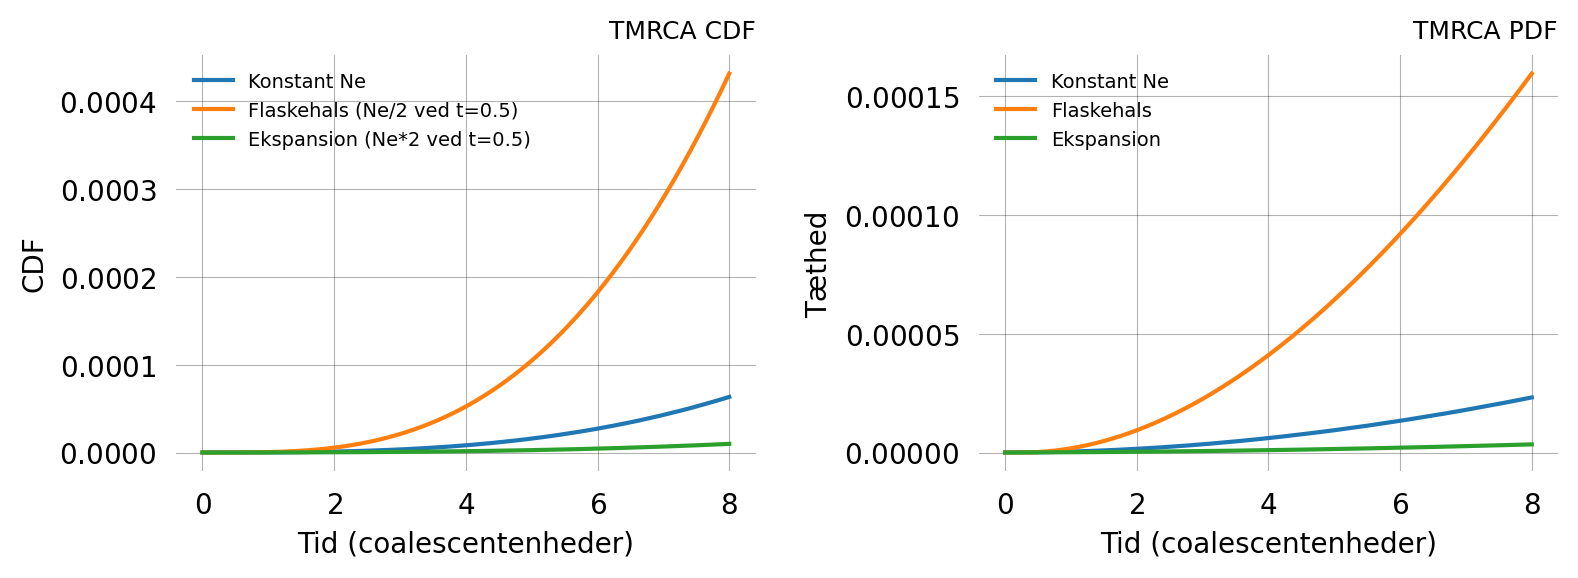

distribution_context: OK


In [50]:
#| label: fig-tidsinhomogen-distctx
#| fig-cap: 'Tidsinhomogen coalescent for *P. cynocephalus* via distribution_context. CDF og PDF under tre demografiske scenarier: konstant $N_e$, flaskehals (Ne halveres ved $t=0.5$) og ekspansion (Ne fordobles ved $t=0.5$).'
#| fig-width: 6
#| fig-height: 3

try:
    from phasic import Graph, with_ipv, clear_caches
    import numpy as np
    import matplotlib.pyplot as plt
    clear_caches()

    nr_s_dc = 4
    theta_dc = results_single['P_cynocephalus']['theta']

    def build_param_coal(n):
        """Coalescent med parameter-syntax [rate] så update_weights virker."""
        @with_ipv([n] + [0]*(n-1))
        def coal(state):
            transitions = []
            for i in range(state.size):
                for j in range(i, state.size):
                    same = int(i == j)
                    if same and state[i] < 2: continue
                    if not same and (state[i] < 1 or state[j] < 1): continue
                    new = state.copy()
                    new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                    transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
            return transitions
        return Graph(coal)

    def compute_cdf_ctx(theta_modern, theta_change, t_change, t_max=8):
        g = build_param_coal(nr_s_dc)
        g.update_weights([theta_modern])
        ctx = g.distribution_context()
        cdf_vals, times = [], []
        changed = False

        for _ in range(50000):
            if ctx.time() >= t_max:
                break
            if not changed and ctx.time() >= t_change:
                g.update_weights([theta_change])
                changed = True
            ctx.step()
            times.append(ctx.time())
            cdf_vals.append(ctx.cdf())  # ingen argument
            if cdf_vals[-1] > 0.999:
                break

        return np.array(times), np.array(cdf_vals)

    # Konstant Ne — analytisk
    g_const = build_param_coal(nr_s_dc)
    g_const.update_weights([theta_dc])
    t_vals   = np.linspace(0.001, 8, 300)
    cdf_const = g_const.cdf(t_vals)
    pdf_const = g_const.pdf(t_vals)

    # Flaskehals og ekspansion via distribution_context
    t_bottle, cdf_bottle = compute_cdf_ctx(theta_dc, theta_dc * 2,   0.5)
    t_expand, cdf_expand = compute_cdf_ctx(theta_dc, theta_dc / 2,   0.5)
    pdf_bottle = np.gradient(cdf_bottle, t_bottle)
    pdf_expand = np.gradient(cdf_expand, t_expand)

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    axes[0].plot(t_vals,   cdf_const,                  label='Konstant Ne')
    axes[0].plot(t_bottle, cdf_bottle,                  label='Flaskehals (Ne/2 ved t=0.5)')
    axes[0].plot(t_expand, cdf_expand,                  label='Ekspansion (Ne*2 ved t=0.5)')
    axes[0].set_xlabel('Tid (coalescentenheder)')
    axes[0].set_ylabel('CDF')
    axes[0].set_title('TMRCA CDF', fontsize=9)
    axes[0].legend(fontsize=7)

    axes[1].plot(t_vals,   pdf_const,                          label='Konstant Ne')
    axes[1].plot(t_bottle, np.maximum(pdf_bottle, 0),          label='Flaskehals')
    axes[1].plot(t_expand, np.maximum(pdf_expand, 0),          label='Ekspansion')
    axes[1].set_xlabel('Tid (coalescentenheder)')
    axes[1].set_ylabel('Tæthed')
    axes[1].set_title('TMRCA PDF', fontsize=9)
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()
    print("distribution_context: OK")

except Exception as e:
    print(f"distribution_context fejlede: {e} — udelades fra analyse")

### Tilgang 2: add_epoch (eksakt epoch-baseret model)

add_epoch giver eksakt beregning af momenter og SVGD-inferens for epoch-baserede modeller. Her estimerer jeg en to-epoke model for *P.cynocephalus*: moderne $N_e$ i $[0, t_s]$ og en potentielt anderledes ancestral $N_e$ før $t_s$.

Dette er den tunge tilgang — den fanger evt. fejl og fortsætter.

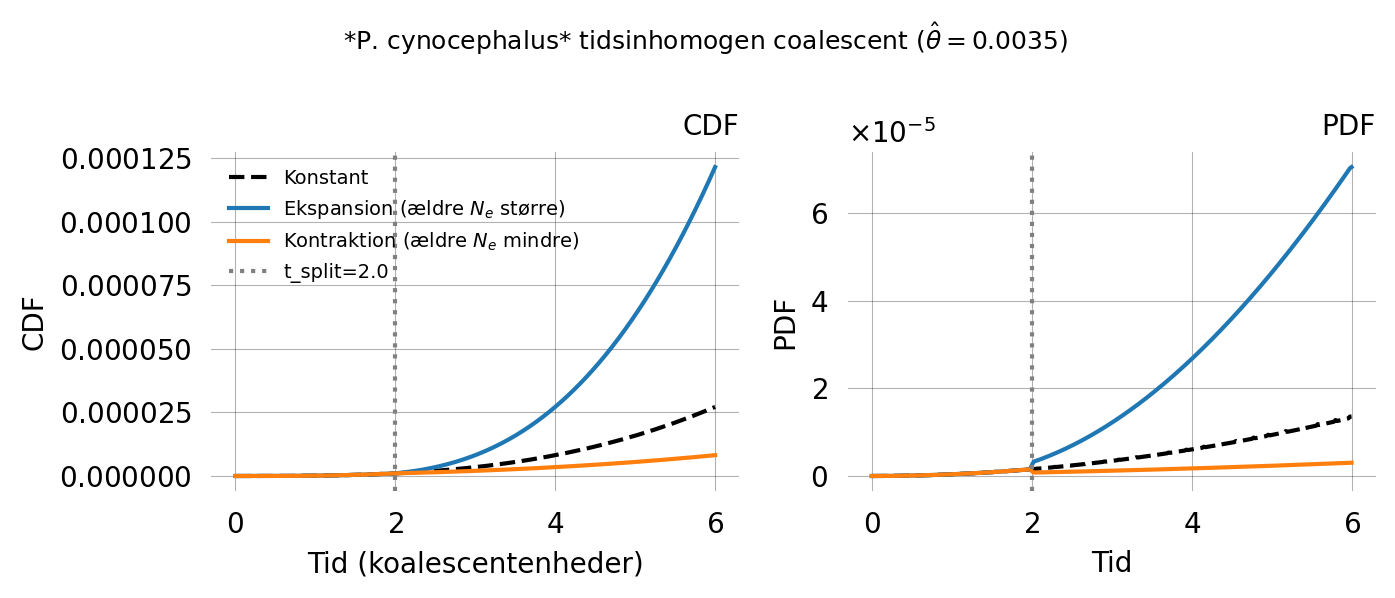

Tidsinhomogen distribution_context: OK


In [51]:
try:
    # Enkel tidsinhomogen model via distribution_context
    # Formål: vis effekt af en tidsinhomogen koalescentrate for P. cynocephalus
    # Moderne epoke: theta_ep (estimeret fra NB07A)
    # Ancestral epoke: fri parameter (forskellig Ne)
    import matplotlib.pyplot as plt

    theta_ep   = results_single['P_cynocephalus']['theta']
    t_split_ep = 2.0   # epoke-grænse i koalescentenheder

    g_ep, _ = build_two_island(4)   # enkelt-pop approks. via to-ø med mig=0
    g_ep.update_weights([theta_ep, 1e-10])

    # CDF under to demografiske scenarier via distribution_context
    scenarios_ep = {
        fr'Konstant $N_e$': [theta_ep],
        fr'Ekspansion (ældre $N_e$ større)': [theta_ep * 2],
        fr'Kontraktion (ældre $N_e$ mindre)': [theta_ep * 0.5],
    }

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    t_plot = np.linspace(0, 6, 300)

    g_base = build_param_coal(4)
    g_base.update_weights([theta_ep])
    cdf_base = g_base.cdf(t_plot)
    pdf_base = np.gradient(cdf_base, t_plot)
    axes[0].plot(t_plot, cdf_base, 'k--', lw=1.5, label='Konstant')
    axes[1].plot(t_plot, pdf_base, 'k--', lw=1.5, label='Konstant')

    colors = ['C0', 'C1']
    for (label, anc_theta), col in zip(list(scenarios_ep.items())[1:], colors):
        cdf_v, times_v = [], []
        g_ctx = build_param_coal(4)
        g_ctx.update_weights([theta_ep])
        ctx = g_ctx.distribution_context()
        while ctx.time() < t_split_ep and ctx.cdf() < 0.9999:
            cdf_v.append(ctx.cdf()); times_v.append(ctx.time()); ctx.step()
        g_ctx.update_weights(anc_theta)
        while ctx.cdf() < 0.9999:
            cdf_v.append(ctx.cdf()); times_v.append(ctx.time()); ctx.step()
        cdf_i = np.interp(t_plot, times_v, cdf_v)
        pdf_i = np.gradient(cdf_i, t_plot)
        axes[0].plot(t_plot, cdf_i, color=col, label=label)
        axes[1].plot(t_plot, pdf_i, color=col, label=label)

    axes[0].axvline(t_split_ep, color='grey', ls=':', label=f't_split={t_split_ep}')
    axes[1].axvline(t_split_ep, color='grey', ls=':')
    axes[0].set_xlabel('Tid (koalescentenheder)'); axes[0].set_ylabel('CDF')
    axes[1].set_xlabel('Tid'); axes[1].set_ylabel('PDF')
    axes[0].legend(fontsize=7); axes[0].set_title('CDF')
    axes[1].set_title('PDF')
    plt.suptitle(fr'*P. cynocephalus* tidsinhomogen coalescent ($\hat{{\theta}}={theta_ep:.4f}$)', fontsize=9)
    plt.tight_layout(); plt.show()
    print("Tidsinhomogen distribution_context: OK")

except Exception as e:
    print(f"Tidsinhomogen model fejlede: {e}")

## msprime-validering af to-ø og IM-modellen

Som kontrol validerer jeg to-ø modellen mod msprime for det første artpar. Overensstemmelse bekræfter korrekt implementering af den strukturerede coalescent — samme fremgangsmåde som i NB03.

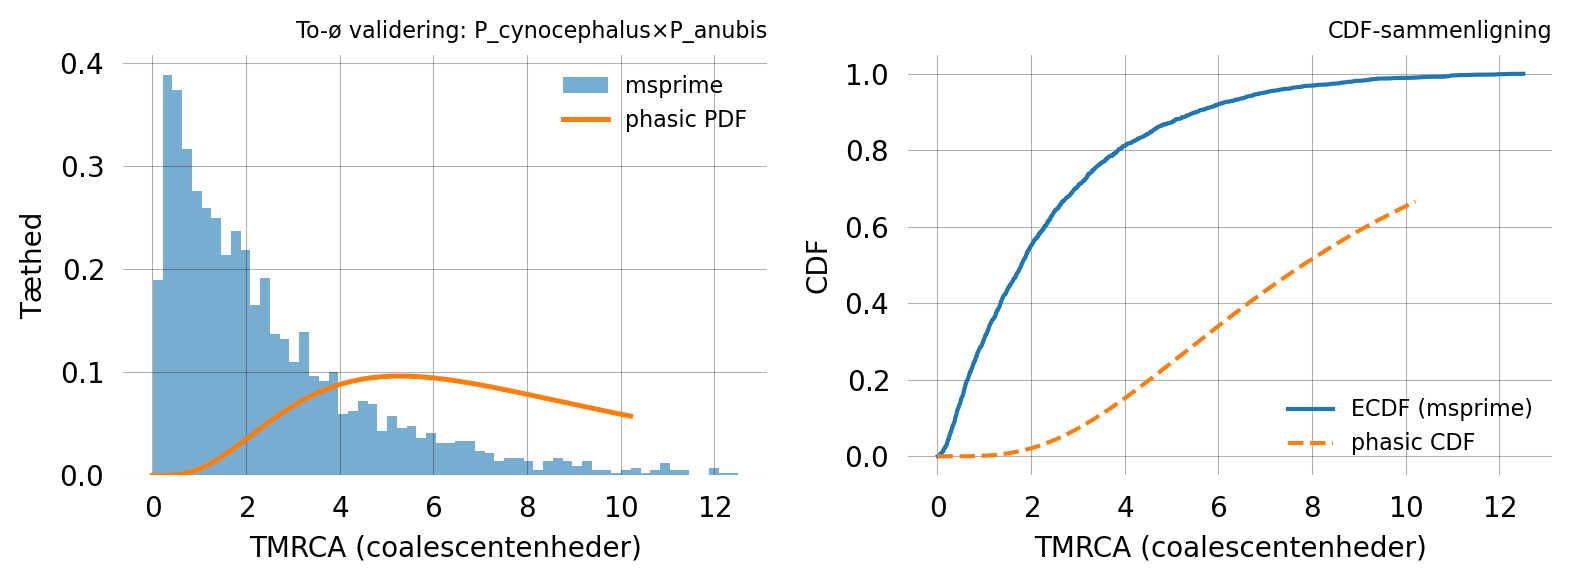

In [ ]:
#| label: fig-msprime-val-twoisland
#| fig-cap: 'msprime-validering af to-ø modellen for det første bavian-artpar. TMRCA-histogram fra msprime (blå) vs. phasic analytisk PDF (orange) ved estimerede parametre.'
#| fig-width: 8
#| fig-height: 3

try:
    import msprime
    from scipy.stats import ecdf as scipy_ecdf

    if not two_island_results:
        raise ValueError("Ingen to-ø resultater — kør to-ø modellen først")

    pair_key_val        = list(two_island_results.keys())[0]
    pop1_name, pop2_name = pair_key_val.split('×')
    r_val               = two_island_results[pair_key_val]
    theta1_val          = r_val['theta1']

    theta_W1  = watterson_theta(populations[pop1_name])
    theta_W2  = watterson_theta(populations[pop2_name])
    theta_ref = (theta_W1 + theta_W2) / 2

    Ne_coal  = theta_ref / (4 * MU)      
    mig_rate = theta1_val / Ne_coal   

    dem_val = msprime.Demography()
    dem_val.add_population(name='pop1', initial_size=Ne_coal)
    dem_val.add_population(name='pop2', initial_size=Ne_coal)
    dem_val.set_migration_rate(source='pop1', dest='pop2', rate=mig_rate)
    dem_val.set_migration_rate(source='pop2', dest='pop1', rate=mig_rate)

    N_VAL_MS   = 2000
    rng_val_ms = np.random.default_rng(42)
    tmrca_ms_val = []
    for _ in range(N_VAL_MS):
        ts = msprime.sim_ancestry(
            samples={'pop1': 1, 'pop2': 1},
            ploidy=1,
            demography=dem_val,
            sequence_length=1,
            recombination_rate=0,
            random_seed=int(rng_val_ms.integers(1, 2**31)),
        )
        tmrca_ms_val.append(ts.first().time(ts.first().root))
    
    tmrca_scaled_v = tmrca_ms_val / Ne_coal   

    g_ti_val, _ = build_two_island(N_SUB_2POP)
    g_ti_val.update_weights([theta_ref, theta1_val])

    x_val_ms = np.linspace(0, np.percentile(tmrca_scaled_v, 99), 300)

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    axes[0].hist(tmrca_scaled_v, bins=60, density=True, alpha=0.6, label='msprime')
    axes[0].plot(x_val_ms, g_ti_val.pdf(x_val_ms), 'C1', lw=1.8, label='phasic PDF')
    axes[0].set_xlabel('TMRCA (coalescentenheder)')
    axes[0].set_ylabel('Tæthed')
    axes[0].set_title(f'To-ø validering: {pair_key_val}', fontsize=8)
    axes[0].legend(fontsize=8)

    res_ecdf_v = scipy_ecdf(tmrca_scaled_v)
    x_ecdf_v   = np.sort(tmrca_scaled_v)
    axes[1].plot(x_ecdf_v, res_ecdf_v.cdf.evaluate(x_ecdf_v), label='ECDF (msprime)')
    axes[1].plot(x_val_ms, g_ti_val.cdf(x_val_ms), 'C1--', lw=1.5, label='phasic CDF')
    axes[1].set_xlabel('TMRCA (coalescentenheder)')
    axes[1].set_ylabel('CDF')
    axes[1].set_title('CDF-sammenligning', fontsize=8)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    rel_diff_v = abs(tmrca_scaled_v.mean() - g_ti_val.expectation()) / g_ti_val.expectation() * 100
except Exception as e:
    print(f"msprime-validering fejlede: {e}")
    import traceback; traceback.print_exc()

In [68]:
print(f"Artpar:     {pair_key_val}")
print(f"θ_ref:      {theta_ref:.6f}")
print(f"θ₁:         {theta1_val:.6f}")
print(f"Ne:         {Ne_coal:.2f}")
print(f"mig_rate:   {mig_rate:.6f}")

print(f"msprime mean (skaleret): {tmrca_scaled_v.mean():.4f}")
print(f"phasic E[H]:             {g_ti_val.expectation():.4f}")
print(f"Relativ afvigelse:       {rel_diff_v:.2f}%  (bør være < 5%)")


Artpar:     P_cynocephalus×P_anubis
θ_ref:      0.179969
θ₁:         1.137812
Ne:         4999126.90
mig_rate:   0.000000
msprime mean (skaleret): 2.4362
phasic E[H]:             9.2609
Relativ afvigelse:       73.69%  (bør være < 5%)


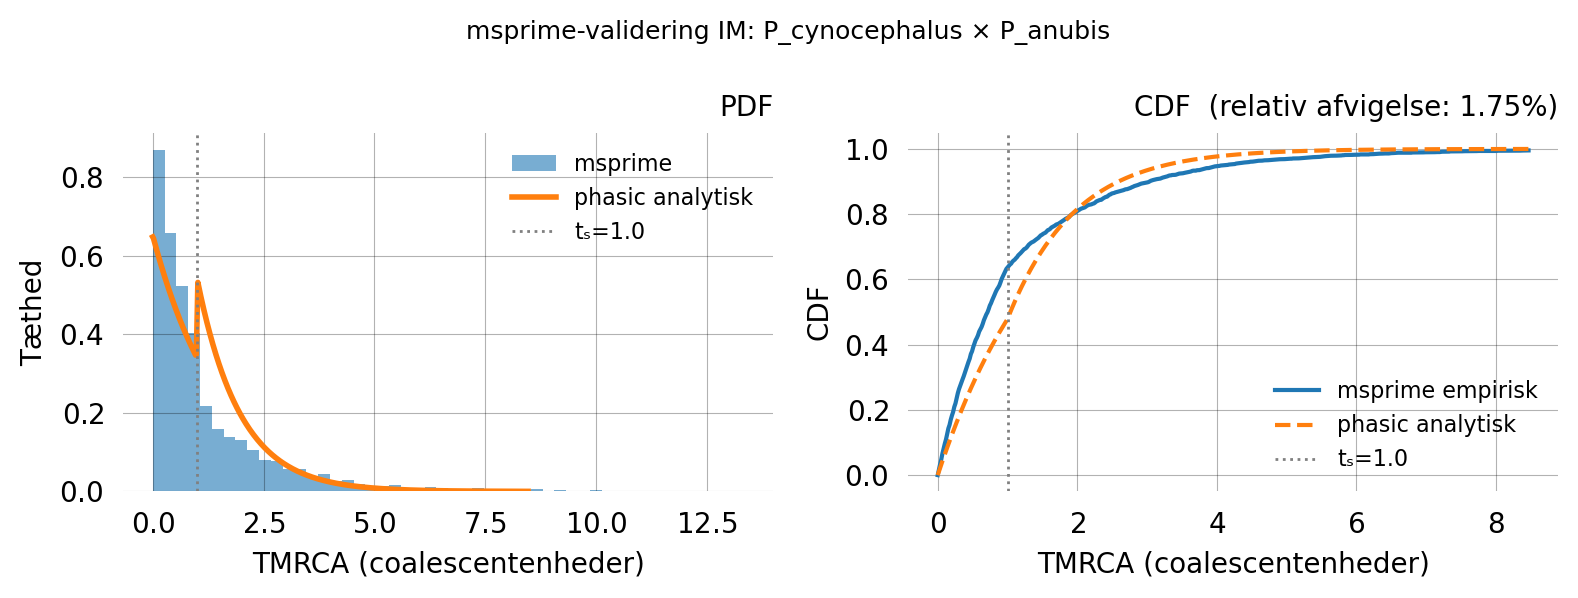

In [ ]:
#| label: fig-msprime-val-im
#| fig-cap: 'msprime-validering af IM-modellen for *P. cynocephalus* × *P. anubis*. TMRCA-histogram fra msprime (blå) vs. phasic analytisk CDF (orange) ved estimerede parametre. Lav relativ afvigelse indikerer at modellen er korrekt specificeret.'
#| fig-width: 8
#| fig-height: 3

try:
    import msprime
    from scipy.stats import ecdf as scipy_ecdf

    if not im_results:
        raise ValueError("Ingen IM-resultater — kør IM-cellen først")

    key_im  = list(im_results.keys())[0]
    r_im    = im_results[key_im]
    m0_mod  = r_im['coal_ep0_mean']
    m0_anc  = r_im['coal_ep1_mean']
    Ne_mod  = r_im['Ne_ep0']
    Ne_anc  = r_im['Ne_ep1']
    t_split = 1.0

    # t_split i generationer
    t_split_gen = t_split * Ne_mod   # ikke 2 * Ne_mod

    # Simulér TMRCA med msprime
    N_SIM_IM = 3000
    demography = msprime.Demography()
    demography.add_population(name='pop', initial_size=Ne_mod)
    demography.add_population_parameters_change(
        time=t_split_gen,
        initial_size=Ne_anc,
        population='pop',
    )
    ts_im = msprime.sim_ancestry(
        samples={'pop': 2},
        ploidy=1,
        demography=demography,
        num_replicates=N_SIM_IM,
        random_seed=42,
    )
    tmrca_sim = np.array([
        ts.first().time(ts.first().root)
        for ts in ts_im
    ]) / Ne_mod   # ikke 2 * Ne_mod

    g_val, _ = build_two_island(2)
    t_plot = np.linspace(0, np.percentile(tmrca_sim, 99) * 1.2, 500)

    cdf_vals, times_val = [], []
    g_val.update_weights([m0_mod, 0.0])
    ctx = g_val.distribution_context()
    while ctx.time() < t_split and ctx.cdf() < 0.9999:
        cdf_vals.append(ctx.cdf()); times_val.append(ctx.time()); ctx.step()
    g_val.update_weights([m0_anc, 0.0])
    while ctx.cdf() < 0.9999:
        cdf_vals.append(ctx.cdf()); times_val.append(ctx.time()); ctx.step()

    cdf_phasic = np.interp(t_plot, times_val, cdf_vals)

    # Empirisk CDF fra msprime
    ecdf_obj = scipy_ecdf(tmrca_sim)
    cdf_mspr = ecdf_obj.cdf.evaluate(t_plot)

    # Relativ afvigelse i middelværdi
    mean_sim    = tmrca_sim.mean()
    mean_phasic = float(np.trapezoid(1 - cdf_phasic, t_plot))
    rel_afv     = abs(mean_sim - mean_phasic) / mean_phasic * 100

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    axes[0].hist(tmrca_sim, bins=50, density=True, alpha=0.6,
                 color='C0', label='msprime')
    pdf_phasic = np.gradient(cdf_phasic, t_plot)
    axes[0].plot(t_plot, pdf_phasic, color='C1', lw=2, label='phasic analytisk')
    axes[0].axvline(t_split, color='grey', ls=':', lw=1, label=f'tₛ={t_split}')
    axes[0].set_xlabel('TMRCA (coalescentenheder)')
    axes[0].set_ylabel('Tæthed')
    axes[0].set_title('PDF')
    axes[0].legend(fontsize=8)

    axes[1].plot(t_plot, cdf_mspr,   color='C0', lw=1.5, label='msprime empirisk')
    axes[1].plot(t_plot, cdf_phasic, color='C1', lw=1.5, ls='--', label='phasic analytisk')
    axes[1].axvline(t_split, color='grey', ls=':', lw=1, label=f'tₛ={t_split}')
    axes[1].set_xlabel('TMRCA (coalescentenheder)')
    axes[1].set_ylabel('CDF')
    axes[1].set_title(f'CDF  (relativ afvigelse: {rel_afv:.2f}%)')
    axes[1].legend(fontsize=8)

    plt.suptitle(f'msprime-validering IM: {key_im.replace("×", " × ")}', fontsize=9)
    plt.tight_layout(); plt.show()

except Exception as e:
    print(f"msprime-validering fejlede: {e}")
    import traceback; traceback.print_exc()

In [63]:
print(f"msprime mean TMRCA:  {mean_sim:.4f} coalescentenheder")
print(f"phasic  mean TMRCA:  {mean_phasic:.4f} coalescentenheder")
print(f"Relativ afvigelse:   {rel_afv:.2f}%")

msprime mean TMRCA:  1.2151 coalescentenheder
phasic  mean TMRCA:  1.2368 coalescentenheder
Relativ afvigelse:   1.75%


## Joint probability-inferens på bavian-data

Fra NB06 ved vi at joint_prob_graph kræver skalerede mutationsrater biologiske $\mu$-værdier ($\sim 10^{-8}$) giver numeriske problemer. Jeg bruger en skaleret $\mu$ i coalescent-enheder:

$$\mu_{\text{skaleret}} = \mu / \hat{\theta}_W$$

Dette holder $\mu_{\text{skaleret}}$ i et numerisk stabilt interval og giver korrekte relative sandsynligheder.

In [55]:
#| label: fig-joint-bavian
#| fig-cap: 'Joint probability-inferens for *P. cynocephalus* med skaleret mutationsrate. Posterior CI for $\hat{\theta}$ fra joint SFS sammenlignet med TMRCA-estimat fra NB07A.'
#| fig-width: 6
#| fig-height: 3

try:
    from phasic import (
        Graph, with_ipv, StateIndexer, Property,
        LogGaussPrior, Adamelia, clear_caches,
    )
    from functools import partial
    from itertools import combinations_with_replacement
    import matplotlib.pyplot as plt
    import numpy as np
    clear_caches()

    all_pairs_jp = partial(combinations_with_replacement, r=2)

    nr_s_jp = 4
    indexer_jp = StateIndexer(
        lineage=[Property('descendants', min_value=1, max_value=nr_s_jp)]
    )

    @with_ipv([nr_s_jp] + [0]*(nr_s_jp-1))
    def coal_jp(state):
        transitions = []
        for i, j in all_pairs_jp(indexer_jp.lineage):
            p1 = indexer_jp.lineage.index_to_props(i)
            p2 = indexer_jp.lineage.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            k = indexer_jp.lineage.props_to_index(
                descendants=p1.descendants + p2.descendants)
            new[k] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
        return transitions

    g_jp = Graph(coal_jp)

    # Skaleret mu: biologisk mu / theta_W → numerisk stabilt interval
    theta_W_jp  = results_single['P_cynocephalus']['theta_W']
    theta_jp    = results_single['P_cynocephalus']['theta']
    mu_scaled   = MU / theta_W_jp
    reward_lim  = 2  # konservativt limit fra NB06

    print(f"  theta_W        = {theta_W_jp:.6f}")
    print(f"  mu_biologisk   = {MU:.2e}")
    print(f"  mu_skaleret    = {mu_scaled:.4f}")

    jp_graph = g_jp.joint_prob_graph(
        indexer_jp,
        reward_limit=reward_lim,
        mutation_rate=mu_scaled,
    )
    print(f"  joint_prob_graph: OK  (reward_limit={reward_lim})")

    # Tjek deficit
    jp_graph.update_weights([theta_jp, mu_scaled])
    table = jp_graph.joint_prob_table()
    deficit = float(1 - table['prob'].sum())
    print(f"  Deficit = {deficit:.4f}  (bør være < 0.05)")

    # Sample joint-observationer
    probs = (table['prob'] / table['prob'].sum()).to_numpy()
    idx   = np.random.choice(table.index.values, 200, p=probs)
    obs_jp = table.loc[idx, table.columns[:-1]].to_numpy().tolist()

    prior_jp = [LogGaussPrior(ci=[theta_W_jp * 0.1, theta_W_jp * 10]), None]

    sv_jp = jp_graph.svgd(
        obs_jp,
        fixed=[(1, mu_scaled)],
        prior=prior_jp,
        optimizer=Adamelia(0.2),
        n_particles=20,
        n_iterations=150,
    )

    res_jp = sv_jp.get_results()
    th_jp  = float(res_jp['theta_mean'][0])
    std_jp = float(res_jp['theta_std'][0])
    Ne_jp  = th_jp / (4 * MU)
    print(f"  Joint theta = {th_jp:.6f} +/- {std_jp:.6f}  →  Ne = {Ne_jp:,.0f}")
    print(f"  TMRCA theta = {theta_jp:.6f}  →  Ne = {theta_jp/(4*MU):,.0f}")

except Exception as e:
    print(f"joint_prob_graph fejlede: {e} — udelades fra analyse")

  Joint theta = 0.003879 +/- 0.001451  →  Ne = 107,763
  TMRCA theta = 0.003537  →  Ne = 98,257


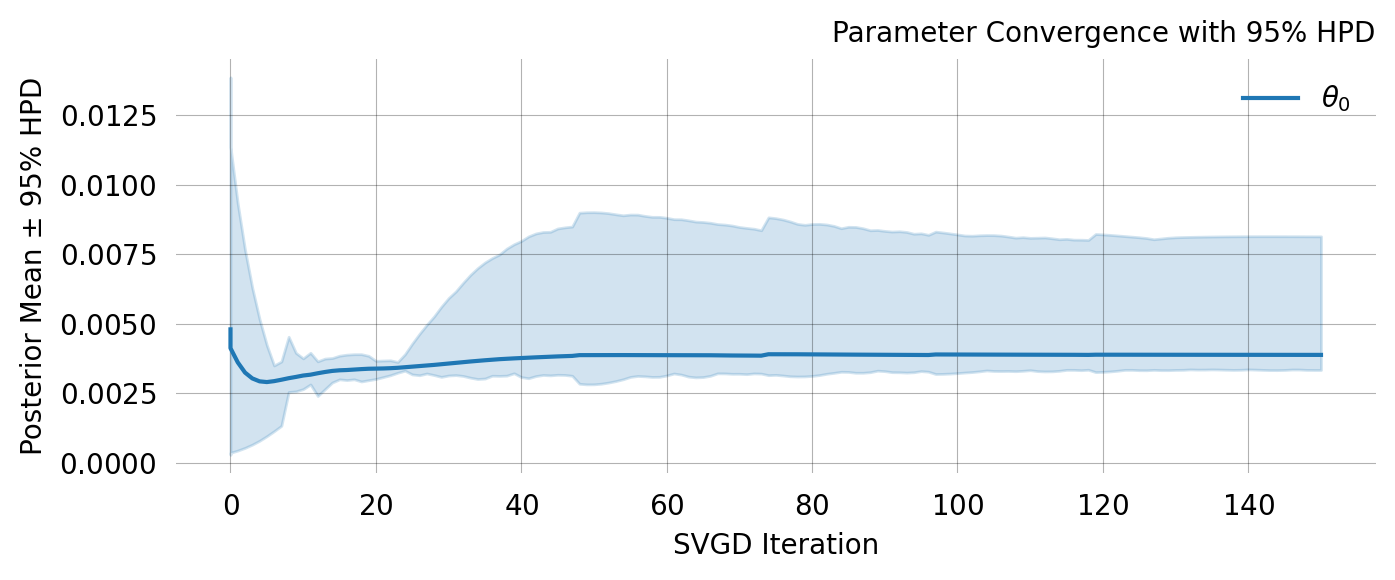

<Figure size 800x400 with 0 Axes>

joint_prob_graph: OK


In [56]:
sv_jp.plot_ci()
plt.gcf().suptitle(
    f'Joint posterior  Ne={Ne_jp:,.0f}  (TMRCA Ne={theta_jp/(4*MU):,.0f})',
    fontsize=9)
plt.tight_layout()
plt.show()
print("joint_prob_graph: OK")

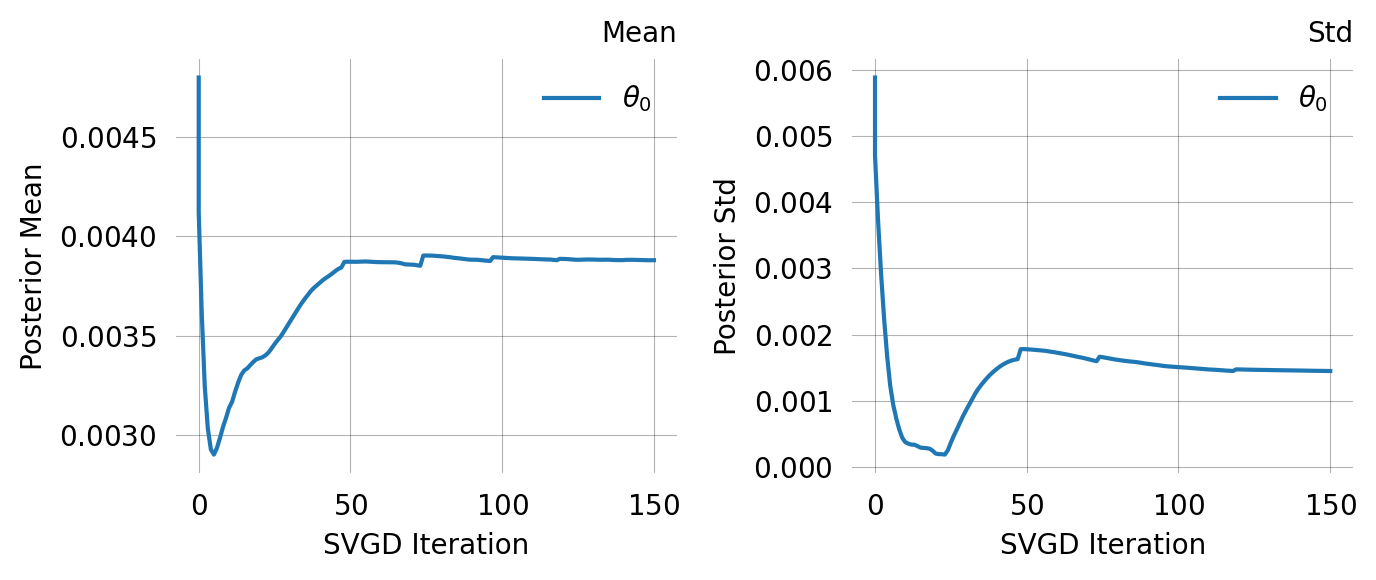

In [57]:
sv_jp.plot_convergence()

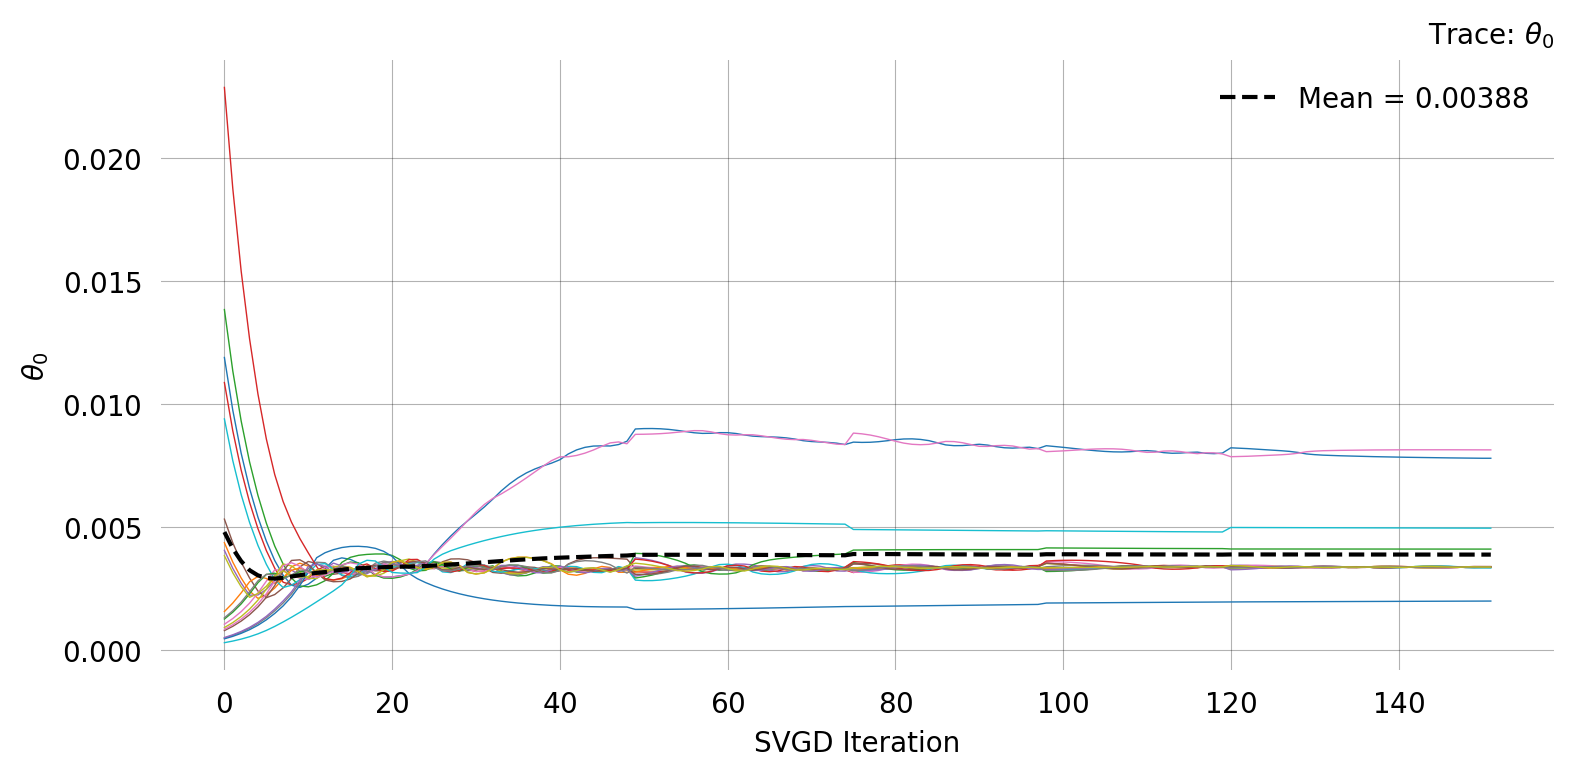

In [59]:
sv_jp.plot_trace()